<a href="https://colab.research.google.com/github/Karolsak/advnaced-sieci/blob/claude%2Fpower-system-ode-solver-gui-011CV6Gg5ZcpsQ1MJkebuExe/Kopia_notatnika_Induction_Motor_Simulation_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tkinter as tk
from tkinter import ttk, messagebox
from tkinter import font as tkFont

import numpy as np
import math
from scipy.integrate import solve_ivp

# Import Matplotlib libraries for embedding plots in Tkinter
from matplotlib.figure import Figure
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg, NavigationToolbar2Tk

class InductionMotorLab:

    def __init__(self, root):
        self.root = root
        self.root.title("Induction Motor Multi-Physics Lab")
        self.root.geometry("1200x800")

        # Set a modern theme
        self.style = ttk.Style()
        self.style.theme_use('clam') # 'clam', 'alt', 'default', 'classic'

        # Configure fonts
        self.default_font = tkFont.nametofont("TkDefaultFont")
        self.default_font.configure(size=10)
        self.heading_font = tkFont.Font(family="Helvetica", size=12, weight="bold")
        self.style.configure("TLabel", font=self.default_font)
        self.style.configure("TButton", font=self.default_font)
        self.style.configure("TEntry", font=self.default_font)
        self.style.configure("TCombobox", font=self.default_font)
        self.style.configure("TLabelframe.Label", font=self.heading_font)
        self.style.configure("TNotebook.Tab", font=('Helvetica', 10, 'bold'))

        # --- Initialize Model Parameters ---
        # These will hold the results of the calculation
        self.R1 = tk.DoubleVar(value=0.25)
        self.X1 = tk.DoubleVar(value=0.0)
        self.R2 = tk.DoubleVar(value=0.0)
        self.X2 = tk.DoubleVar(value=0.0)
        self.Rc = tk.DoubleVar(value=0.0)
        self.Xm = tk.DoubleVar(value=0.0)

        # Rotational losses (Core + Friction & Windage)
        self.P_rot_loss = tk.DoubleVar(value=0.0)

        # Motor rated data
        self.V_line_rated = tk.DoubleVar(value=208.0)
        self.V_phase_rated = tk.DoubleVar(value=208.0 / math.sqrt(3))
        self.poles = tk.IntVar(value=4)
        self.freq = tk.DoubleVar(value=60.0)
        self.N_sync = tk.DoubleVar(value=0.0)
        self.omega_sync = tk.DoubleVar(value=0.0)
        self.update_sync_speeds() # Calculate initial sync speeds

        # Thevenin equivalent parameters
        self.V_th = tk.DoubleVar(value=0.0)
        self.R_th = tk.DoubleVar(value=0.0)
        self.X_th = tk.DoubleVar(value=0.0)

        # Simulation state
        self.simulation_running = False
        self.transient_solution = None

        # --- Create Main GUI Structure ---
        self.main_paned_window = ttk.PanedWindow(root, orient=tk.VERTICAL)
        self.main_paned_window.pack(fill=tk.BOTH, expand=True)

        # Top frame for Notebook (controls, inputs)
        self.top_frame = ttk.Frame(self.main_paned_window, height=350)
        self.main_paned_window.add(self.top_frame, weight=2)

        # Bottom frame for main plot (will be replaced by notebook)
        # We will create the notebook and put it in the top_frame
        self.top_frame.grid_rowconfigure(0, weight=1)
        self.top_frame.grid_columnconfigure(0, weight=1)

        self.notebook = ttk.Notebook(self.top_frame)
        self.notebook.grid(row=0, column=0, sticky='nsew', padx=5, pady=5)

        # --- Create Tabs ---
        self.tab_params = ttk.Frame(self.notebook, padding=10)
        self.tab_steady_state = ttk.Frame(self.notebook, padding=10)
        self.tab_dynamic_sim = ttk.Frame(self.notebook, padding=10)
        self.tab_losses_thermal = ttk.Frame(self.notebook, padding=10)
        self.tab_economic = ttk.Frame(self.notebook, padding=10)
        self.tab_control = ttk.Frame(self.notebook, padding=10)
        self.tab_multiphysics = ttk.Frame(self.notebook, padding=10)

        self.notebook.add(self.tab_params, text=" 1. Parameters & Tests ")
        self.notebook.add(self.tab_steady_state, text=" 2. Steady-State Analysis ")
        self.notebook.add(self.tab_dynamic_sim, text=" 3. Dynamic (ODE) Simulation ")
        self.notebook.add(self.tab_losses_thermal, text=" 4. Losses & Thermal ")
        self.notebook.add(self.tab_economic, text=" 5. Economic Analysis ")
        self.notebook.add(self.tab_control, text=" 6. Control Methods ")
        self.notebook.add(self.tab_multiphysics, text=" 7. Multi-Physics Concepts ")

        # --- Populate Tabs ---
        self.create_params_tab()
        self.create_steady_state_tab()
        self.create_dynamic_sim_tab()
        self.create_losses_thermal_tab()
        self.create_economic_tab()
        self.create_control_tab()
        self.create_multiphysics_tab()

        # --- Configure Responsive Layout ---
        # This is the key to auto-scaling
        self.root.grid_rowconfigure(0, weight=1)
        self.root.grid_columnconfigure(0, weight=1)
        # self.main_paned_window is already packed to fill/expand

        # Configure tab frames to resize
        self.tab_params.grid_rowconfigure(0, weight=1)
        self.tab_params.grid_columnconfigure(0, weight=1)
        self.tab_params.grid_columnconfigure(1, weight=1)

        self.tab_steady_state.grid_rowconfigure(0, weight=1)
        self.tab_steady_state.grid_columnconfigure(1, weight=3) # Plot gets more space
        self.tab_steady_state.grid_columnconfigure(0, weight=1)

        self.tab_dynamic_sim.grid_rowconfigure(1, weight=1)
        self.tab_dynamic_sim.grid_columnconfigure(0, weight=1)

        self.tab_losses_thermal.grid_rowconfigure(0, weight=1)
        self.tab_losses_thermal.grid_columnconfigure(0, weight=1)
        self.tab_losses_thermal.grid_columnconfigure(1, weight=1)

        self.tab_economic.grid_rowconfigure(0, weight=1)
        self.tab_economic.grid_columnconfigure(0, weight=1)
        self.tab_economic.grid_columnconfigure(1, weight=1)

        self.tab_control.grid_rowconfigure(0, weight=1)
        self.tab_control.grid_columnconfigure(0, weight=1)

        self.tab_multiphysics.grid_rowconfigure(0, weight=1)
        self.tab_multiphysics.grid_columnconfigure(0, weight=1)

        # Automatically run calculation on startup *after* all tabs are built
        self.run_parameter_calculation()


    # --- Tab Creation Methods ---

    def create_params_tab(self):
        """Populates the 'Parameters & Tests' tab."""

        main_frame = ttk.Frame(self.tab_params)
        main_frame.grid(row=0, column=0, columnspan=2, sticky='nsew', padx=5, pady=5)
        main_frame.grid_columnconfigure(0, weight=1)
        main_frame.grid_columnconfigure(1, weight=1)

        # --- Left Column: Test Inputs ---
        left_frame = ttk.Frame(main_frame)
        left_frame.grid(row=0, column=0, sticky='nsew', padx=10)

        # Motor Data
        lf_motor = ttk.Labelframe(left_frame, text="Motor Rated Data")
        lf_motor.pack(fill=tk.X, expand=True, pady=5)

        ttk.Label(lf_motor, text="V_line (V):").grid(row=0, column=0, sticky='w', padx=5, pady=2)
        self.entry_V_line = ttk.Entry(lf_motor, textvariable=self.V_line_rated, width=10)
        self.entry_V_line.grid(row=0, column=1, sticky='we', padx=5, pady=2)

        ttk.Label(lf_motor, text="Frequency (Hz):").grid(row=1, column=0, sticky='w', padx=5, pady=2)
        self.entry_freq = ttk.Entry(lf_motor, textvariable=self.freq, width=10)
        self.entry_freq.grid(row=1, column=1, sticky='we', padx=5, pady=2)

        ttk.Label(lf_motor, text="Poles:").grid(row=2, column=0, sticky='w', padx=5, pady=2)
        self.entry_poles = ttk.Entry(lf_motor, textvariable=self.poles, width=10)
        self.entry_poles.grid(row=2, column=1, sticky='we', padx=5, pady=2)

        ttk.Label(lf_motor, text="Stator R1 (Ω):").grid(row=3, column=0, sticky='w', padx=5, pady=2)
        self.entry_R1 = ttk.Entry(lf_motor, textvariable=self.R1, width=10)
        self.entry_R1.grid(row=3, column=1, sticky='we', padx=5, pady=2)

        # No-Load Test
        self.nl_V = tk.DoubleVar(value=208.0)
        self.nl_I = tk.DoubleVar(value=6.49)
        self.nl_P = tk.DoubleVar(value=332.0)

        lf_nl = ttk.Labelframe(left_frame, text="No-Load Test (60 Hz)")
        lf_nl.pack(fill=tk.X, expand=True, pady=10)

        ttk.Label(lf_nl, text="V_L (V):").grid(row=0, column=0, sticky='w', padx=5, pady=2)
        ttk.Entry(lf_nl, textvariable=self.nl_V, width=10).grid(row=0, column=1, sticky='we', padx=5, pady=2)
        ttk.Label(lf_nl, text="I_L (A):").grid(row=1, column=0, sticky='w', padx=5, pady=2)
        ttk.Entry(lf_nl, textvariable=self.nl_I, width=10).grid(row=1, column=1, sticky='we', padx=5, pady=2)
        ttk.Label(lf_nl, text="P_in (W):").grid(row=2, column=0, sticky='w', padx=5, pady=2)
        ttk.Entry(lf_nl, textvariable=self.nl_P, width=10).grid(row=2, column=1, sticky='we', padx=5, pady=2)

        # Locked-Rotor Test
        self.lr_V = tk.DoubleVar(value=78.5)
        self.lr_I = tk.DoubleVar(value=42.0)
        self.lr_P = tk.DoubleVar(value=2116.8)
        self.lr_f = tk.DoubleVar(value=60.0) # Test frequency

        lf_lr = ttk.Labelframe(left_frame, text="Locked-Rotor Test")
        lf_lr.pack(fill=tk.X, expand=True, pady=10)

        ttk.Label(lf_lr, text="V_L (V):").grid(row=0, column=0, sticky='w', padx=5, pady=2)
        ttk.Entry(lf_lr, textvariable=self.lr_V, width=10).grid(row=0, column=1, sticky='we', padx=5, pady=2)
        ttk.Label(lf_lr, text="I_L (A):").grid(row=1, column=0, sticky='w', padx=5, pady=2)
        ttk.Entry(lf_lr, textvariable=self.lr_I, width=10).grid(row=1, column=1, sticky='we', padx=5, pady=2)
        ttk.Label(lf_lr, text="P_in (W):").grid(row=2, column=0, sticky='w', padx=5, pady=2)
        ttk.Entry(lf_lr, textvariable=self.lr_P, width=10).grid(row=2, column=1, sticky='we', padx=5, pady=2)
        ttk.Label(lf_lr, text="Freq (Hz):").grid(row=3, column=0, sticky='w', padx=5, pady=2)
        ttk.Entry(lf_lr, textvariable=self.lr_f, width=10).grid(row=3, column=1, sticky='we', padx=5, pady=2)

        # --- Right Column: Calculated Parameters ---
        right_frame = ttk.Frame(main_frame)
        right_frame.grid(row=0, column=1, sticky='nsew', padx=10)

        lf_results = ttk.Labelframe(right_frame, text="Calculated Equivalent Circuit")
        lf_results.pack(fill=tk.X, expand=True, pady=5)

        self.lbl_R1 = ttk.Label(lf_results, text="R1 (Stator): {:.4f} Ω".format(self.R1.get()))
        self.lbl_R1.pack(anchor='w', padx=10, pady=3)
        self.lbl_R2 = ttk.Label(lf_results, text="R2 (Rotor): ... Ω")
        self.lbl_R2.pack(anchor='w', padx=10, pady=3)
        self.lbl_X1 = ttk.Label(lf_results, text="X1 (Stator): ... Ω")
        self.lbl_X1.pack(anchor='w', padx=10, pady=3)
        self.lbl_X2 = ttk.Label(lf_results, text="X2 (Rotor): ... Ω")
        self.lbl_X2.pack(anchor='w', padx=10, pady=3)
        self.lbl_Rc = ttk.Label(lf_results, text="Rc (Core): ... Ω")
        self.lbl_Rc.pack(anchor='w', padx=10, pady=3)
        self.lbl_Xm = ttk.Label(lf_results, text="Xm (Mag.): ... Ω")
        self.lbl_Xm.pack(anchor='w', padx=10, pady=3)
        self.lbl_Prot = ttk.Label(lf_results, text="P_rot_loss: ... W")
        self.lbl_Prot.pack(anchor='w', padx=10, pady=3)

        lf_thevenin = ttk.Labelframe(right_frame, text="Calculated Thevenin Equivalent")
        lf_thevenin.pack(fill=tk.X, expand=True, pady=10)

        self.lbl_Vth = ttk.Label(lf_thevenin, text="V_th (V): ... V")
        self.lbl_Vth.pack(anchor='w', padx=10, pady=3)
        self.lbl_Rth = ttk.Label(lf_thevenin, text="R_th (Ω): ... Ω")
        self.lbl_Rth.pack(anchor='w', padx=10, pady=3)
        self.lbl_Xth = ttk.Label(lf_thevenin, text="X_th (Ω): ... Ω")
        self.lbl_Xth.pack(anchor='w', padx=10, pady=3)

        # --- Control Buttons ---
        button_frame = ttk.Frame(right_frame)
        button_frame.pack(fill=tk.X, pady=20)

        self.btn_calculate = ttk.Button(button_frame, text="Calculate Parameters", command=self.run_parameter_calculation)
        self.btn_calculate.pack(side=tk.LEFT, fill=tk.X, expand=True, padx=5)

        self.btn_reset_params = ttk.Button(button_frame, text="Reset to Defaults", command=self.reset_inputs)
        self.btn_reset_params.pack(side=tk.LEFT, fill=tk.X, expand=True, padx=5)

        # Automatically run calculation on startup
        # self.run_parameter_calculation() # <-- BUG: Moved this call to the end of __init__

    def create_steady_state_tab(self):
        """Populates the 'Steady-State Analysis' tab."""
        self.tab_steady_state.grid_columnconfigure(0, weight=1, minsize=300)
        self.tab_steady_state.grid_columnconfigure(1, weight=3)
        self.tab_steady_state.grid_rowconfigure(0, weight=1)

        # --- Left Column: Controls & Readouts ---
        controls_frame = ttk.Frame(self.tab_steady_state)
        controls_frame.grid(row=0, column=0, sticky='nsew', padx=10, pady=10)

        # Operating Point Slider
        lf_op_point = ttk.Labelframe(controls_frame, text="Operating Point Control")
        lf_op_point.pack(fill=tk.X, pady=10)

        self.op_point_slip = tk.DoubleVar(value=0.03) # Default 3% slip
        self.op_point_speed_rpm = tk.DoubleVar(value=self.N_sync.get() * (1 - 0.03))

        ttk.Label(lf_op_point, text="Slip (s):").grid(row=0, column=0, sticky='w', padx=5, pady=5)
        self.lbl_op_slip = ttk.Label(lf_op_point, text="{:.4f}".format(self.op_point_slip.get()))
        self.lbl_op_slip.grid(row=0, column=1, sticky='w', padx=5, pady=5)

        self.slider_slip = ttk.Scale(lf_op_point, from_=0.001, to=1.0, orient=tk.HORIZONTAL,
                                     variable=self.op_point_slip, command=self.update_operating_point)
        self.slider_slip.grid(row=1, column=0, columnspan=2, sticky='ew', padx=5, pady=5)

        ttk.Label(lf_op_point, text="Speed (RPM):").grid(row=2, column=0, sticky='w', padx=5, pady=5)
        self.lbl_op_speed = ttk.Label(lf_op_point, text="{:.1f}".format(self.op_point_speed_rpm.get()))
        self.lbl_op_speed.grid(row=2, column=1, sticky='w', padx=5, pady=5)

        # Readouts
        lf_readouts = ttk.Labelframe(controls_frame, text="Performance at Operating Point")
        lf_readouts.pack(fill=tk.X, expand=True, pady=10)

        self.lbl_op_T_out = ttk.Label(lf_readouts, text="T_out (Nm): ...")
        self.lbl_op_T_out.pack(anchor='w', padx=10, pady=4)
        self.lbl_op_P_out = ttk.Label(lf_readouts, text="P_out (kW): ...")
        self.lbl_op_P_out.pack(anchor='w', padx=10, pady=4)
        self.lbl_op_I_line = ttk.Label(lf_readouts, text="I_line (A): ...")
        self.lbl_op_I_line.pack(anchor='w', padx=10, pady=4)
        self.lbl_op_PF = ttk.Label(lf_readouts, text="PF (%): ...")
        self.lbl_op_PF.pack(anchor='w', padx=10, pady=4)
        self.lbl_op_Eff = ttk.Label(lf_readouts, text="Efficiency (%): ...")
        self.lbl_op_Eff.pack(anchor='w', padx=10, pady=4)
        self.lbl_op_P_in = ttk.Label(lf_readouts, text="P_in (kW): ...")
        self.lbl_op_P_in.pack(anchor='w', padx=10, pady=4)

        # Summary
        lf_summary = ttk.Labelframe(controls_frame, text="Key Performance Metrics")
        lf_summary.pack(fill=tk.X, expand=True, pady=10)

        self.lbl_T_max = ttk.Label(lf_summary, text="T_max (Nm): ...")
        self.lbl_T_max.pack(anchor='w', padx=10, pady=4)
        self.lbl_s_max_T = ttk.Label(lf_summary, text="s @ T_max: ...")
        self.lbl_s_max_T.pack(anchor='w', padx=10, pady=4)
        self.lbl_T_start = ttk.Label(lf_summary, text="T_start (Nm): ...")
        self.lbl_T_start.pack(anchor='w', padx=10, pady=4)

        # --- Right Column: Plot ---
        plot_frame = ttk.Frame(self.tab_steady_state)
        plot_frame.grid(row=0, column=1, sticky='nsew', padx=5, pady=5)
        plot_frame.grid_rowconfigure(0, weight=1)
        plot_frame.grid_columnconfigure(0, weight=1)

        self.fig_steady_state = Figure(figsize=(8, 6), dpi=100)
        self.ax_torque = self.fig_steady_state.add_subplot(111)

        self.ax_current = self.ax_torque.twinx() # Share x-axis for current
        self.fig_steady_state.tight_layout(rect=[0.05, 0.05, 0.85, 0.95]) # Adjust layout

        self.canvas_steady_state = FigureCanvasTkAgg(self.fig_steady_state, master=plot_frame)
        self.canvas_steady_state.get_tk_widget().pack(fill=tk.BOTH, expand=True)

        toolbar = NavigationToolbar2Tk(self.canvas_steady_state, plot_frame, pack_toolbar=False)
        toolbar.update()
        toolbar.pack(side=tk.BOTTOM, fill=tk.X)

        self.plot_steady_state_curves()
        self.update_operating_point()

    def create_dynamic_sim_tab(self):
        """Populates the 'Dynamic (ODE) Simulation' tab."""
        self.tab_dynamic_sim.grid_columnconfigure(0, weight=1)
        self.tab_dynamic_sim.grid_rowconfigure(0, weight=0) # Control frame
        self.tab_dynamic_sim.grid_rowconfigure(1, weight=1) # Plot frame

        # --- Top Frame: Controls ---
        control_frame = ttk.Frame(self.tab_dynamic_sim)
        control_frame.grid(row=0, column=0, sticky='new', padx=10, pady=10)

        lf_dyn_params = ttk.Labelframe(control_frame, text="Simulation Parameters")
        lf_dyn_params.pack(side=tk.LEFT, fill=tk.X, expand=True, padx=5)

        self.sim_J = tk.DoubleVar(value=0.1) # Total Inertia (kg-m^2)
        self.sim_T_load = tk.DoubleVar(value=20.0) # Load Torque (Nm)
        self.sim_t_span = tk.DoubleVar(value=5.0) # Sim duration (s)
        self.sim_solver = tk.StringVar(value='RK45')

        ttk.Label(lf_dyn_params, text="Inertia (J) (kg-m^2):").grid(row=0, column=0, sticky='w', padx=5, pady=2)
        ttk.Entry(lf_dyn_params, textvariable=self.sim_J, width=10).grid(row=0, column=1, sticky='we', padx=5, pady=2)

        ttk.Label(lf_dyn_params, text="Load Torque (T_load) (Nm):").grid(row=1, column=0, sticky='w', padx=5, pady=2)
        ttk.Entry(lf_dyn_params, textvariable=self.sim_T_load, width=10).grid(row=1, column=1, sticky='we', padx=5, pady=2)

        ttk.Label(lf_dyn_params, text="Sim Time (s):").grid(row=0, column=2, sticky='w', padx=5, pady=2)
        ttk.Entry(lf_dyn_params, textvariable=self.sim_t_span, width=10).grid(row=0, column=3, sticky='we', padx=5, pady=2)

        ttk.Label(lf_dyn_params, text="Solver:").grid(row=1, column=2, sticky='w', padx=5, pady=2)
        ttk.Combobox(lf_dyn_params, textvariable=self.sim_solver, values=['RK45', 'RK23', 'DOP853', 'Euler'], width=8).grid(row=1, column=3, sticky='we', padx=5, pady=2)

        lf_dyn_buttons = ttk.Frame(control_frame)
        lf_dyn_buttons.pack(side=tk.LEFT, fill=tk.X, expand=True, padx=20)

        self.btn_run_dyn_sim = ttk.Button(lf_dyn_buttons, text="Start Dynamic Sim", command=self.run_dynamic_simulation)
        self.btn_run_dyn_sim.pack(fill=tk.X, pady=2)

        self.btn_reset_dyn_sim = ttk.Button(lf_dyn_buttons, text="Reset Plot", command=self.reset_dynamic_plot)
        self.btn_reset_dyn_sim.pack(fill=tk.X, pady=2)

        self.dyn_sim_status = tk.StringVar(value="Status: Ready")
        ttk.Label(control_frame, textvariable=self.dyn_sim_status).pack(side=tk.LEFT, fill=tk.X, expand=True, padx=5)


        # --- Bottom Frame: Plot ---
        plot_frame = ttk.Frame(self.tab_dynamic_sim)
        plot_frame.grid(row=1, column=0, sticky='nsew', padx=5, pady=5)
        plot_frame.grid_rowconfigure(0, weight=1)
        plot_frame.grid_columnconfigure(0, weight=1)

        self.fig_dynamic = Figure(figsize=(8, 6), dpi=100)
        self.ax_dynamic = self.fig_dynamic.add_subplot(111)
        self.ax_dynamic.set_title("Dynamic Simulation: Motor Startup")
        self.ax_dynamic.set_xlabel("Time (s)")
        self.ax_dynamic.set_ylabel("Speed (RPM)")
        self.ax_dynamic.grid(True)
        self.fig_dynamic.tight_layout()

        self.canvas_dynamic = FigureCanvasTkAgg(self.fig_dynamic, master=plot_frame)
        self.canvas_dynamic.get_tk_widget().pack(fill=tk.BOTH, expand=True)

        toolbar_dyn = NavigationToolbar2Tk(self.canvas_dynamic, plot_frame, pack_toolbar=False)
        toolbar_dyn.update()
        toolbar_dyn.pack(side=tk.BOTTOM, fill=tk.X)

    def create_losses_thermal_tab(self):
        """Populates the 'Losses & Thermal' tab."""
        main_frame = ttk.Frame(self.tab_losses_thermal)
        main_frame.grid(row=0, column=0, columnspan=2, sticky='nsew', padx=5, pady=5)
        main_frame.grid_columnconfigure(0, weight=1)
        main_frame.grid_columnconfigure(1, weight=1)

        # --- Left Column: Loss Breakdown ---
        left_frame = ttk.Frame(main_frame)
        left_frame.grid(row=0, column=0, sticky='nsew', padx=10)

        lf_losses = ttk.Labelframe(left_frame, text="Detailed Loss Breakdown (at Op. Point)")
        lf_losses.pack(fill=tk.X, expand=True, pady=10)

        self.lbl_loss_Pscl = ttk.Label(lf_losses, text="Stator Copper (Pscl): ... W")
        self.lbl_loss_Pscl.pack(anchor='w', padx=10, pady=5)
        self.lbl_loss_Prcl = ttk.Label(lf_losses, text="Rotor Copper (Prcl): ... W")
        self.lbl_loss_Prcl.pack(anchor='w', padx=10, pady=5)
        self.lbl_loss_Pcore = ttk.Label(lf_losses, text="Core Loss (Pcore): ... W")
        self.lbl_loss_Pcore.pack(anchor='w', padx=10, pady=5)
        self.lbl_loss_Prot = ttk.Label(lf_losses, text="Friction & Windage (P_f&w): ... W")
        self.lbl_loss_Prot.pack(anchor='w', padx=10, pady=5)
        self.lbl_loss_Pstray = ttk.Label(lf_losses, text="Stray Load Loss (Pstray): ... W")
        self.lbl_loss_Pstray.pack(anchor='w', padx=10, pady=5)

        ttk.Separator(lf_losses, orient=tk.HORIZONTAL).pack(fill=tk.X, pady=10, padx=5)

        self.lbl_loss_Ptotal = ttk.Label(lf_losses, text="Total Losses (Ploss): ... W", font=self.heading_font)
        self.lbl_loss_Ptotal.pack(anchor='w', padx=10, pady=5)

        ttk.Button(lf_losses, text="Update Losses from Op. Point",
                   command=self.update_losses_and_thermal).pack(pady=10)

        # --- Right Column: Simple Thermal Model ---
        right_frame = ttk.Frame(main_frame)
        right_frame.grid(row=0, column=1, sticky='nsew', padx=10)

        lf_thermal = ttk.Labelframe(right_frame, text="Simple Thermal Model (Steady-State)")
        lf_thermal.pack(fill=tk.X, expand=True, pady=10)

        self.thermal_R_th_winding = tk.DoubleVar(value=0.15) # K/W
        self.thermal_R_th_core = tk.DoubleVar(value=0.5) # K/W
        self.thermal_T_ambient = tk.DoubleVar(value=25.0) # deg C

        ttk.Label(lf_thermal, text="R_th_winding (K/W):").grid(row=0, column=0, sticky='w', padx=5, pady=3)
        ttk.Entry(lf_thermal, textvariable=self.thermal_R_th_winding, width=10).grid(row=0, column=1, sticky='w', padx=5, pady=3)

        ttk.Label(lf_thermal, text="R_th_core (K/W):").grid(row=1, column=0, sticky='w', padx=5, pady=3)
        ttk.Entry(lf_thermal, textvariable=self.thermal_R_th_core, width=10).grid(row=1, column=1, sticky='w', padx=5, pady=3)

        ttk.Label(lf_thermal, text="Ambient Temp (°C):").grid(row=2, column=0, sticky='w', padx=5, pady=3)
        ttk.Entry(lf_thermal, textvariable=self.thermal_T_ambient, width=10).grid(row=2, column=1, sticky='w', padx=5, pady=3)

        lf_temps = ttk.Labelframe(right_frame, text="Estimated Temperatures")
        lf_temps.pack(fill=tk.X, expand=True, pady=20)

        self.lbl_temp_winding = ttk.Label(lf_temps, text="T_winding: ... °C", font=self.heading_font)
        self.lbl_temp_winding.pack(anchor='w', padx=10, pady=5)

        self.lbl_temp_core = ttk.Label(lf_temps, text="T_core: ... °C", font=self.heading_font)
        self.lbl_temp_core.pack(anchor='w', padx=10, pady=5)

    def create_economic_tab(self):
        """Populates the 'Economic Analysis' tab."""
        main_frame = ttk.Frame(self.tab_economic)
        main_frame.grid(row=0, column=0, columnspan=2, sticky='nsew', padx=5, pady=5)
        main_frame.grid_columnconfigure(0, weight=1)
        main_frame.grid_columnconfigure(1, weight=1)

        # --- Left Column: Inputs ---
        left_frame = ttk.Frame(main_frame)
        left_frame.grid(row=0, column=0, sticky='nsew', padx=10)

        lf_econ_inputs = ttk.Labelframe(left_frame, text="Cost Parameters")
        lf_econ_inputs.pack(fill=tk.X, expand=True, pady=10)

        self.econ_cost_kwh = tk.DoubleVar(value=0.15) # $/kWh
        self.econ_op_hours_day = tk.DoubleVar(value=8.0)

        ttk.Label(lf_econ_inputs, text="Energy Cost ($/kWh):").grid(row=0, column=0, sticky='w', padx=5, pady=3)
        ttk.Entry(lf_econ_inputs, textvariable=self.econ_cost_kwh, width=10).grid(row=0, column=1, sticky='w', padx=5, pady=3)

        ttk.Label(lf_econ_inputs, text="Operating Hours/Day:").grid(row=1, column=0, sticky='w', padx=5, pady=3)
        ttk.Entry(lf_econ_inputs, textvariable=self.econ_op_hours_day, width=10).grid(row=1, column=1, sticky='w', padx=5, pady=3)

        ttk.Button(lf_econ_inputs, text="Calculate Economics",
                   command=self.update_economics).grid(row=2, column=0, columnspan=2, pady=10)

        # --- Right Column: Results ---
        right_frame = ttk.Frame(main_frame)
        right_frame.grid(row=0, column=1, sticky='nsew', padx=10)

        lf_econ_results = ttk.Labelframe(right_frame, text="Operating Cost (at Op. Point)")
        lf_econ_results.pack(fill=tk.X, expand=True, pady=10)

        self.lbl_econ_power = ttk.Label(lf_econ_results, text="Power Consumption (P_in): ... kW")
        self.lbl_econ_power.pack(anchor='w', padx=10, pady=5)
        self.lbl_econ_cost_day = ttk.Label(lf_econ_results, text="Cost per Day: ... $")
        self.lbl_econ_cost_day.pack(anchor='w', padx=10, pady=5)
        self.lbl_econ_cost_month = ttk.Label(lf_econ_results, text="Cost per Month (30d): ... $")
        self.lbl_econ_cost_month.pack(anchor='w', padx=10, pady=5)
        self.lbl_econ_cost_year = ttk.Label(lf_econ_results, text="Cost per Year (365d): ... $", font=self.heading_font)
        self.lbl_econ_cost_year.pack(anchor='w', padx=10, pady=5)

        ttk.Label(lf_econ_results, text="Note: Assumes constant operation at the\n steady-state operating point.",
                  font=self.default_font).pack(pady=20)

    def create_control_tab(self):
        """Placeholder for 'Control Methods' tab."""
        lf_control = ttk.Labelframe(self.tab_control, text="Advanced Machine Control (Conceptual)")
        lf_control.pack(fill=tk.BOTH, expand=True, padx=10, pady=10)

        text = """
This tab demonstrates where advanced control logic would be implemented.

1.  **Scalar Control (V/f):**
    * Simplest method. Maintains a constant Volts/Hertz ratio.
    * Used for simple speed control (e.g., fans, pumps).
    * **Control:** Adjust frequency (f) and V_line (V) proportionally.
    * *Try it:* Go to the 'Parameters' tab, change 'Frequency' and 'V_line' (e.g., to 30 Hz and 104V) and re-calculate parameters and curves.

2.  **Vector Control (Field-Oriented Control, FOC):**
    * Complex, high-performance method.
    * Decouples torque-producing (Iq) and flux-producing (Id) currents.
    * Requires a real-time processor (DSP/FPGA) and current/position sensors.
    * Provides precise torque and speed control, similar to a DC motor.
    * **Simulation:** Would require solving complex d-q axis differential equations, far beyond the scope of this steady-state model.
"""
        lbl_text = ttk.Label(lf_control, text=text, justify=tk.LEFT, relief=tk.SOLID, padding=10, borderwidth=1)
        lbl_text.pack(fill=tk.BOTH, expand=True, padx=10, pady=10)

    def create_multiphysics_tab(self):
        """Placeholder for 'Multi-Physics' tab."""
        lf_mp = ttk.Labelframe(self.tab_multiphysics, text="Multi-Physics Simulation Concepts")
        lf_mp.pack(fill=tk.BOTH, expand=True, padx=10, pady=10)

        text = """
A true multi-physics simulation couples different physical domains simultaneously.
This application uses a *decoupled* approach (electrical -> thermal).

**1. Coupled Electromagnetic-Thermal:**
* **Concept:** The electrical simulation calculates copper (I^2*R) and core losses. These losses are used as heat sources in a thermal (Finite Element/CFD) model. The thermal model calculates new temperatures.
* **Feedback:** The new temperatures change the winding resistances (R1, R2).
* **This App:** We do this manually. The 'Losses' tab calculates heat. The 'Thermal' tab calculates temperature. You could manually update R1/R2 on the 'Params' tab and re-run. A coupled sim does this every time step.

**2. Mechanical Stress Analysis:**
* **Concept:** The 'Dynamic Simulation' calculates electromagnetic torque (T_dev).
* **Analysis:** This T_dev(t) profile would be an input to a Finite Element Analysis (FEA) model of the shaft.
* **Results:** The FEA model would calculate:
    * Transient torque ripple on the shaft.
    * Mechanical stress (von Mises) and strain.
    * Bearing loads and estimated fatigue life.
    * Torsional vibrations and critical speeds.
"""
        lbl_text = ttk.Label(lf_mp, text=text, justify=tk.LEFT, relief=tk.SOLID, padding=10, borderwidth=1)
        lbl_text.pack(fill=tk.BOTH, expand=True, padx=10, pady=10)

    # --- Calculation & Plotting Methods ---

    def update_sync_speeds(self):
        """Updates synchronous speeds based on freq and poles."""
        try:
            f = self.freq.get()
            p = self.poles.get()
            if p == 0 or f == 0:
                return
            n_s = (120 * f) / p
            om_s = (4 * math.pi * f) / p
            self.N_sync.set(n_s)
            self.omega_sync.set(om_s)
        except Exception as e:
            messagebox.showerror("Error", f"Invalid motor data: {e}")

    def reset_inputs(self):
        """Resets test data to the problem default."""
        self.V_line_rated.set(208.0)
        self.freq.set(60.0)
        self.poles.set(4)
        self.R1.set(0.25)

        self.nl_V.set(208.0)
        self.nl_I.set(6.49)
        self.nl_P.set(332.0)

        self.lr_V.set(78.5)
        self.lr_I.set(42.0)
        self.lr_P.set(2116.8)
        self.lr_f.set(60.0)

        self.run_parameter_calculation()

    def run_parameter_calculation(self):
        """
        Solves Example 6.1.
        Calculates R1, X1, R2, X2, Rc, Xm from test data.
        """
        try:
            # Get base parameters
            self.update_sync_speeds()
            self.V_phase_rated.set(self.V_line_rated.get() / math.sqrt(3))
            v_ph = self.V_phase_rated.get()
            r1 = self.R1.get()

            # --- No-Load Test ---
            v_nl_L = self.nl_V.get()
            i_nl = self.nl_I.get()
            p_nl = self.nl_P.get()
            v_nl_ph = v_nl_L / math.sqrt(3)

            # 1. Stator copper loss at no load
            p_scl_nl = 3 * (i_nl**2) * r1

            # 2. Rotational loss (Core + F&W)
            p_rot = p_nl - p_scl_nl
            self.P_rot_loss.set(p_rot)

            # 3. Core loss resistance (Rc)
            # This is an approximation, assumes P_rot is all core loss for Rc calc
            # A better way: P_rot = P_core + P_fw
            # I_c = P_rot / (3 * v_nl_ph) -> This is I_c + I_fw_equiv...
            # Let's use the standard textbook approximation:
            i_c = p_rot / (3 * v_nl_ph) # Current to supply rotational losses
            rc = v_nl_ph / i_c
            self.Rc.set(rc)

            # 4. Magnetizing current (Im) and Reactance (Xm)
            i_m = math.sqrt(i_nl**2 - i_c**2)
            xm = v_nl_ph / i_m
            self.Xm.set(xm)

            # --- Locked-Rotor Test ---
            v_lr_L = self.lr_V.get()
            i_lr = self.lr_I.get()
            p_lr = self.lr_P.get()
            f_lr = self.lr_f.get()
            f_rated = self.freq.get()
            v_lr_ph = v_lr_L / math.sqrt(3)

            # 5. Equivalent LR impedance
            z_lr = v_lr_ph / i_lr

            # 6. Equivalent LR resistance
            r_lr = p_lr / (3 * (i_lr**2))

            # 7. Equivalent LR reactance *at test frequency*
            x_lr_test = math.sqrt(z_lr**2 - r_lr**2)

            # 8. Scale reactance to rated frequency
            x_lr_rated = x_lr_test * (f_rated / f_lr)

            # 9. Calculate R2
            # R_lr = R1 + R2
            r2 = r_lr - r1
            self.R2.set(r2)

            # 10. Split X1 and X2 (NEMA/IEEE Standard assumptions)
            # For cage motors, common to assume X1 = X2
            x1 = x_lr_rated / 2.0
            x2 = x_lr_rated / 2.0
            self.X1.set(x1)
            self.X2.set(x2)

            # --- Calculate Thevenin Equivalent ---
            z_m = (1j * xm * rc) / (rc + 1j * xm)
            z1 = r1 + 1j * x1

            v_th_complex = v_ph * (z_m / (z1 + z_m))
            z_th_complex = (z_m * z1) / (z_m + z1)

            self.V_th.set(abs(v_th_complex))
            self.R_th.set(z_th_complex.real)
            self.X_th.set(z_th_complex.imag)

            # --- Update GUI Labels ---
            self.lbl_R1.config(text="R1 (Stator): {:.4f} Ω".format(r1))
            self.lbl_R2.config(text="R2 (Rotor): {:.4f} Ω".format(r2))
            self.lbl_X1.config(text="X1 (Stator): {:.4f} Ω".format(x1))
            self.lbl_X2.config(text="X2 (Rotor): {:.4f} Ω".format(x2))
            self.lbl_Rc.config(text="Rc (Core): {:.4f} Ω".format(rc))
            self.lbl_Xm.config(text="Xm (Mag.): {:.4f} Ω".format(xm))
            self.lbl_Prot.config(text="P_rot_loss: {:.2f} W".format(p_rot))

            self.lbl_Vth.config(text="V_th (V): {:.2f} V".format(self.V_th.get()))
            self.lbl_Rth.config(text="R_th (Ω): {:.4f} Ω".format(self.R_th.get()))
            self.lbl_Xth.config(text="X_th (Ω): {:.4f} Ω".format(self.X_th.get()))

            # Re-plot curves with new data
            self.plot_steady_state_curves()
            self.update_operating_point()

        except Exception as e:
            messagebox.showerror("Calculation Error", f"An error occurred: {e}")

    def get_performance_at_slip(self, slip):
        """
        Calculates all performance metrics for a given slip.
        Returns a dictionary of values.
        """
        if slip == 0:
            slip = 1e-9 # Avoid divide by zero

        # Get parameters
        v_ph = self.V_phase_rated.get()
        r1 = self.R1.get()
        x1 = self.X1.get()
        r2 = self.R2.get()
        x2 = self.X2.get()
        rc = self.Rc.get()
        xm = self.Xm.get()
        v_th = self.V_th.get()
        r_th = self.R_th.get()
        x_th = self.X_th.get()
        om_s = self.omega_sync.get()
        p_rot_loss = self.P_rot_loss.get() # P_core + P_fw

        if om_s == 0: # Not initialized
            return {}

        # --- Thevenin-based Calculation ---
        # 1. Developed Torque
        denominator = (r_th + r2/slip)**2 + (x_th + x2)**2
        T_dev = (3 * (v_th**2) * (r2/slip)) / (om_s * denominator)

        # 2. Output Torque (subtract rotational losses)
        # T_rot_loss = P_rot_loss / (om_s * (1 - slip)) # This is incorrect
        # P_rot_loss is assumed constant. P_out = P_dev - P_rot_loss
        P_dev = T_dev * om_s * (1-slip)
        P_out = P_dev - p_rot_loss
        if P_out < 0: P_out = 0.0 # Motor region

        T_out = P_out / (om_s * (1-slip)) if (1-slip) != 0 else 0

        # --- Full Circuit Calculation (for I1, PF, Losses) ---
        z_m = (1j * xm * rc) / (rc + 1j * xm)
        z_2_s = (r2/slip) + 1j*x2
        z_parallel = (z_m * z_2_s) / (z_m + z_2_s)
        z_total = (r1 + 1j*x1) + z_parallel

        I1 = (v_ph + 0j) / z_total
        I1_mag = abs(I1)

        # 3. Input Power and PF
        P_in = 3 * (v_ph * I1.conjugate()).real
        S_in = 3 * v_ph * I1_mag
        PF = P_in / S_in if S_in != 0 else 1.0

        # 4. Efficiency
        Eff = P_out / P_in if P_in > 0 else 0.0

        # 5. Loss Breakdown
        P_scl = 3 * (I1_mag**2) * r1

        # Need E1 (voltage across parallel branch)
        E1 = v_ph - I1 * (r1 + 1j*x1)
        E1_mag = abs(E1)

        I2 = E1 / z_2_s
        I2_mag = abs(I2)

        P_rcl = 3 * (I2_mag**2) * r2
        P_core = 3 * (E1_mag**2) / rc

        # P_fw = P_rot_loss - P_core. This is an approx.
        P_fw = p_rot_loss - P_core
        if P_fw < 0: P_fw = 0 # Our Rc is based on P_rot_loss, so this is approx.

        P_stray = 0 # Stray losses are notoriously hard to model here.

        P_loss_total = P_scl + P_rcl + P_core + P_fw + P_stray

        return {
            "slip": slip,
            "speed_rpm": self.N_sync.get() * (1-slip),
            "T_dev": T_dev,

            "T_out": T_out,
            "P_out_kW": P_out / 1000.0,
            "I_line": I1_mag,
            "PF_pct": PF * 100.0,
            "Eff_pct": Eff * 100.0,
            "P_in_kW": P_in / 1000.0,
            "P_scl_W": P_scl,
            "P_rcl_W": P_rcl,
            "P_core_W": P_core,
            "P_fw_W": P_fw,
            "P_stray_W": P_stray,
            "P_loss_total_W": P_loss_total
        }

    def plot_steady_state_curves(self):
        """Calculates and plots the full T-s and I-s curves."""
        try:
            slips = np.linspace(0.001, 1.0, 200)
            speeds_rpm = self.N_sync.get() * (1 - slips)

            T_out_list = []
            I_line_list = []
            Eff_list = []

            for s in slips:
                res = self.get_performance_at_slip(s)
                T_out_list.append(res.get("T_out", 0))
                I_line_list.append(res.get("I_line", 0))
                Eff_list.append(res.get("Eff_pct", 0))

            # --- Find Key Points ---
            # Max Torque
            s_max_T = self.R2.get() / math.sqrt(self.R_th.get()**2 + (self.X_th.get() + self.X2.get())**2)
            if s_max_T > 1.0: s_max_T = 1.0
            res_max_T = self.get_performance_at_slip(s_max_T)
            T_max = res_max_T.get("T_out", 0)

            # Starting Torque (s=1)
            res_start = self.get_performance_at_slip(1.0)
            T_start = res_start.get("T_out", 0)

            # Update summary labels
            self.lbl_T_max.config(text="T_max (Nm): {:.2f}".format(T_max))
            self.lbl_s_max_T.config(text="s @ T_max: {:.4f}".format(s_max_T))
            self.lbl_T_start.config(text="T_start (Nm): {:.2f}".format(T_start))

            # --- Plotting ---
            self.ax_torque.clear()
            self.ax_current.clear()

            # Torque Plot (Blue)
            color = 'tab:blue'
            self.ax_torque.set_xlabel('Speed (RPM)')
            self.ax_torque.set_ylabel('Output Torque (Nm)', color=color)
            self.ax_torque.plot(speeds_rpm, T_out_list, color=color, linewidth=2, label="Torque (T_out)")
            self.ax_torque.tick_params(axis='y', labelcolor=color)
            self.ax_torque.grid(True, linestyle='--')

            # Current Plot (Red)
            color = 'tab:red'
            self.ax_current.set_ylabel('Line Current (A)', color=color)
            self.ax_current.plot(speeds_rpm, I_line_list, color=color, linestyle='--', linewidth=2, label="Current (I_line)")
            self.ax_current.tick_params(axis='y', labelcolor=color)

            self.ax_torque.set_title('Steady-State Performance Curves')
            self.fig_steady_state.tight_layout(rect=[0.05, 0.05, 0.85, 0.95])

            # Draw a vertical line for the operating point
            self.op_point_line = self.ax_torque.axvline(x=self.op_point_speed_rpm.get(), color='green', linestyle=':', linewidth=2, label='Op. Point')

            self.canvas_steady_state.draw()

        except Exception as e:
            messagebox.showerror("Plotting Error", f"Could not plot curves: {e}")

    def update_operating_point(self, *args):
        """Callback from slider. Updates all readouts."""
        try:
            slip = self.op_point_slip.get()
            speed = self.N_sync.get() * (1 - slip)
            self.op_point_speed_rpm.set(speed)

            self.lbl_op_slip.config(text="{:.4f}".format(slip))
            self.lbl_op_speed.config(text="{:.1f}".format(speed))

            # Get performance
            res = self.get_performance_at_slip(slip)
            if not res:
                return

            # Update labels
            self.lbl_op_T_out.config(text="T_out (Nm): {:.2f}".format(res.get("T_out", 0)))
            self.lbl_op_P_out.config(text="P_out (kW): {:.3f}".format(res.get("P_out_kW", 0)))
            self.lbl_op_I_line.config(text="I_line (A): {:.2f}".format(res.get("I_line", 0)))
            self.lbl_op_PF.config(text="PF (%): {:.1f}".format(res.get("PF_pct", 0)))
            self.lbl_op_Eff.config(text="Efficiency (%): {:.1f}".format(res.get("Eff_pct", 0)))
            self.lbl_op_P_in.config(text="P_in (kW): {:.3f}".format(res.get("P_in_kW", 0)))

            # Update vertical line on plot
            if hasattr(self, 'op_point_line'):
                self.op_point_line.set_xdata([speed, speed])
            self.canvas_steady_state.draw()

        except Exception as e:
            # This can fire rapidly from the slider, so don't use a messagebox
            print(f"Slider update error: {e}")

    def run_dynamic_simulation(self):
        """
        Solves the mechanical ODE for motor startup.
        J * d(omega_m)/dt = T_dev(omega_m) - T_load
        """
        try:
            self.dyn_sim_status.set("Status: Running...")
            self.root.update_idletasks() # Force GUI update

            J = self.sim_J.get()
            T_load = self.sim_T_load.get()
            t_sim = self.sim_t_span.get()
            solver = self.sim_solver.get()
            if solver == 'Euler':
                solver = 'RK23' # Use a similar low-order, 'RK45' is default

            om_s = self.omega_sync.get()

            def motor_ode(t, y):
                """The ODE system: y = [omega_m]"""
                omega_m = y[0]

                # Calculate slip
                if om_s == omega_m:
                    slip = 0
                else:
                    slip = (om_s - omega_m) / om_s

                # Bound slip
                if slip <= 0: # Motoring
                    slip = 1e-9
                if slip > 1: # Startup
                    slip = 1.0

                # Get developed torque at this slip
                # We only need T_dev, so we can use the fast Thevenin calc
                r2 = self.R2.get()
                v_th = self.V_th.get()
                r_th = self.R_th.get()
                x_th = self.X_th.get()
                x2 = self.X2.get()

                denominator = (r_th + r2/slip)**2 + (x_th + x2)**2
                T_dev = (3 * (v_th**2) * (r2/slip)) / (om_s * denominator)

                # The ODE
                d_omega_m_dt = (1/J) * (T_dev - T_load)

                return [d_omega_m_dt]

            # Solve the ODE
            # y0 = [omega_m_initial]
            y0 = [0.0]
            t_span = [0, t_sim]

            # We use max_step to ensure we capture the dynamics smoothly
            self.transient_solution = solve_ivp(motor_ode, t_span, y0, method=solver,
                                                dense_output=True, max_step=t_sim/100.0)

            sol = self.transient_solution

            # Plot results
            self.ax_dynamic.clear()

            # Convert omega_m (rad/s) to RPM
            speeds_rpm = sol.y[0] * (60 / (2 * math.pi))

            self.ax_dynamic.plot(sol.t, speeds_rpm, linewidth=2, label="Motor Speed")

            # Add N_sync and T_load lines
            self.ax_dynamic.axhline(y=self.N_sync.get(), color='r', linestyle='--', label='N_sync')

            # Find steady-state speed
            try:
                ss_speed = speeds_rpm[-1]
                self.ax_dynamic.axhline(y=ss_speed, color='g', linestyle=':', label='Steady-State Speed')
            except: pass

            self.ax_dynamic.set_title("Dynamic Simulation: Motor Startup")
            self.ax_dynamic.set_xlabel("Time (s)")
            self.ax_dynamic.set_ylabel("Speed (RPM)")
            self.ax_dynamic.legend()
            self.ax_dynamic.grid(True)
            self.fig_dynamic.tight_layout()
            self.canvas_dynamic.draw()

            self.dyn_sim_status.set(f"Status: Solved in {sol.nfev} steps.")

        except Exception as e:
            self.dyn_sim_status.set("Status: Error.")
            messagebox.showerror("Dynamic Sim Error", f"Could not solve ODE: {e}")

    def reset_dynamic_plot(self):
        """Clears the dynamic simulation plot."""
        self.ax_dynamic.clear()
        self.ax_dynamic.set_title("Dynamic Simulation: Motor Startup")
        self.ax_dynamic.set_xlabel("Time (s)")
        self.ax_dynamic.set_ylabel("Speed (RPM)")
        self.ax_dynamic.grid(True)
        self.fig_dynamic.tight_layout()
        self.canvas_dynamic.draw()
        self.dyn_sim_status.set("Status: Ready")
        self.transient_solution = None

    def update_losses_and_thermal(self):
        """Updates the loss and thermal tabs based on the slider's op. point."""
        try:
            slip = self.op_point_slip.get()
            res = self.get_performance_at_slip(slip)
            if not res:
                return

            # Update Loss Labels
            self.lbl_loss_Pscl.config(text="Stator Copper (Pscl): {:.2f} W".format(res.get("P_scl_W", 0)))
            self.lbl_loss_Prcl.config(text="Rotor Copper (Prcl): {:.2f} W".format(res.get("P_rcl_W", 0)))
            self.lbl_loss_Pcore.config(text="Core Loss (Pcore): {:.2f} W".format(res.get("P_core_W", 0)))
            self.lbl_loss_Prot.config(text="Friction & Windage (P_f&w): {:.2f} W".format(res.get("P_fw_W", 0)))
            self.lbl_loss_Pstray.config(text="Stray Load Loss (Pstray): {:.2f} W".format(res.get("P_stray_W", 0)))
            self.lbl_loss_Ptotal.config(text="Total Losses (Ploss): {:.2f} W".format(res.get("P_loss_total_W", 0)))

            # Update Thermal Model
            t_amb = self.thermal_T_ambient.get()
            r_th_w = self.thermal_R_th_winding.get()
            r_th_c = self.thermal_R_th_core.get()

            # Simple superposition: Winding heat = (Pscl + Prcl)
            # Core heat = Pcore
            # This is a major simplification.
            p_winding_loss = res.get("P_scl_W", 0) + res.get("P_rcl_W", 0)
            p_core_loss = res.get("P_core_W", 0)

            t_winding = t_amb + (p_winding_loss * r_th_w)
            t_core = t_amb + (p_core_loss * r_th_c)

            self.lbl_temp_winding.config(text="T_winding: {:.1f} °C".format(t_winding))
            self.lbl_temp_core.config(text="T_core: {:.1f} °C".format(t_core))

        except Exception as e:
            messagebox.showerror("Thermal Error", f"Could not update thermal model: {e}")

    def update_economics(self):
        """Updates the economic analysis based on the slider's op. point."""
        try:
            slip = self.op_point_slip.get()
            res = self.get_performance_at_slip(slip)
            if not res:
                return

            p_in_kw = res.get("P_in_kW", 0)
            cost_kwh = self.econ_cost_kwh.get()
            hours_day = self.econ_op_hours_day.get()

            cost_day = p_in_kw * hours_day * cost_kwh
            cost_month = cost_day * 30
            cost_year = cost_day * 365

            self.lbl_econ_power.config(text="Power Consumption (P_in): {:.3f} kW".format(p_in_kw))
            self.lbl_econ_cost_day.config(text="Cost per Day: ${:.2f}".format(cost_day))
            self.lbl_econ_cost_month.config(text="Cost per Month (30d): ${:.2f}".format(cost_month))
            self.lbl_econ_cost_year.config(text="Cost per Year (365d): ${:.2f}".format(cost_year))

        except Exception as e:
            messagebox.showerror("Economic Error", f"Could not calculate costs: {e}")


if __name__ == "__main__":
    root = tk.Tk()
    app = InductionMotorLab(root)
    root.mainloop()

TclError: no display name and no $DISPLAY environment variable

### Removing Tkinter Dependency for Headless Operation

To truly run the `InductionMotorLab`'s simulation logic without any `tkinter` dependency or errors in environments like Google Colab, you would need to refactor the `InductionMotorLab` class. The main change involves removing all `tk.XXXVar` objects and replacing them with standard Python variables (e.g., `float`, `int`, `str`).

Here's how you could modify the `InductionMotorLab` class to be fully headless. This version removes the Tkinter-specific variable types and GUI-related methods, keeping only the core calculation logic.

```python
# This is a conceptual refactoring. You would need to apply these changes
# to the original InductionMotorLab class definition.

class HeadlessInductionMotorLab:

    def __init__(self):
        # --- Initialize Model Parameters (now standard Python types) ---
        self.R1 = 0.25
        self.X1 = 0.0
        self.R2 = 0.0
        self.X2 = 0.0
        self.Rc = 0.0
        self.Xm = 0.0

        self.P_rot_loss = 0.0

        self.V_line_rated = 208.0
        self.V_phase_rated = 208.0 / math.sqrt(3)
        self.poles = 4
        self.freq = 60.0
        self.N_sync = 0.0
        self.omega_sync = 0.0
        self.update_sync_speeds()

        self.V_th = 0.0
        self.R_th = 0.0
        self.X_th = 0.0

        # --- Test Data (now standard Python types) ---
        self.nl_V = 208.0
        self.nl_I = 6.49
        self.nl_P = 332.0

        self.lr_V = 78.5
        self.lr_I = 42.0
        self.lr_P = 2116.8
        self.lr_f = 60.0

        # --- Simulation Parameters (now standard Python types) ---
        self.sim_J = 0.1
        self.sim_T_load = 20.0
        self.sim_t_span = 5.0
        self.sim_solver = 'RK45'

        # Run initial calculation
        self.run_parameter_calculation()

    # All `update_sync_speeds`, `run_parameter_calculation`, `get_performance_at_slip`,
    # `run_dynamic_simulation` (with modifications for sim_solver string),
    # and other pure calculation methods would remain largely the same,
    # but would directly access `self.variable` instead of `self.variable.get()`.
    # All GUI-specific methods like `create_params_tab`, `plot_steady_state_curves` etc.,
    # would be removed or refactored to return data instead of plotting.

    def update_sync_speeds(self):
        try:
            f = self.freq
            p = self.poles
            if p == 0 or f == 0:
                return
            n_s = (120 * f) / p
            om_s = (4 * math.pi * f) / p
            self.N_sync = n_s
            self.omega_sync = om_s
        except Exception as e:
            print(f"Error updating sync speeds: {e}") # Or handle as needed

    def run_parameter_calculation(self):
        try:
            self.update_sync_speeds()
            self.V_phase_rated = self.V_line_rated / math.sqrt(3)
            v_ph = self.V_phase_rated
            r1 = self.R1

            # No-Load Test
            v_nl_L = self.nl_V
            i_nl = self.nl_I
            p_nl = self.nl_P
            v_nl_ph = v_nl_L / math.sqrt(3)

            p_scl_nl = 3 * (i_nl**2) * r1
            p_rot = p_nl - p_scl_nl
            self.P_rot_loss = p_rot

            i_c = p_rot / (3 * v_nl_ph)
            rc = v_nl_ph / i_c
            self.Rc = rc

            i_m = math.sqrt(i_nl**2 - i_c**2)
            xm = v_nl_ph / i_m
            self.Xm = xm

            # Locked-Rotor Test
            v_lr_L = self.lr_V
            i_lr = self.lr_I
            p_lr = self.lr_P
            f_lr = self.lr_f
            f_rated = self.freq
            v_lr_ph = v_lr_L / math.sqrt(3)

            z_lr = v_lr_ph / i_lr
            r_lr = p_lr / (3 * (i_lr**2))
            x_lr_test = math.sqrt(z_lr**2 - r_lr**2)
            x_lr_rated = x_lr_test * (f_rated / f_lr)

            r2 = r_lr - r1
            self.R2 = r2

            x1 = x_lr_rated / 2.0
            x2 = x_lr_rated / 2.0
            self.X1 = x1
            self.X2 = x2

            # Thevenin Equivalent
            z_m = (1j * xm * rc) / (rc + 1j * xm)
            z1 = r1 + 1j * x1

            v_th_complex = v_ph * (z_m / (z1 + z_m))
            z_th_complex = (z_m * z1) / (z_m + z1)

            self.V_th = abs(v_th_complex)
            self.R_th = z_th_complex.real
            self.X_th = z_th_complex.imag

        except Exception as e:
            print(f"Calculation Error: {e}")

    def get_performance_at_slip(self, slip):
        if slip == 0:
            slip = 1e-9

        v_ph = self.V_phase_rated
        r1 = self.R1
        x1 = self.X1
        r2 = self.R2
        x2 = self.X2
        rc = self.Rc
        xm = self.Xm
        v_th = self.V_th
        r_th = self.R_th
        x_th = self.X_th
        om_s = self.omega_sync
        p_rot_loss = self.P_rot_loss

        if om_s == 0:
            return {}

        denominator = (r_th + r2/slip)**2 + (x_th + x2)**2
        T_dev = (3 * (v_th**2) * (r2/slip)) / (om_s * denominator)

        P_dev = T_dev * om_s * (1-slip)
        P_out = P_dev - p_rot_loss
        if P_out < 0: P_out = 0.0

        T_out = P_out / (om_s * (1-slip)) if (1-slip) != 0 else 0

        z_m = (1j * xm * rc) / (rc + 1j * xm)
        z_2_s = (r2/slip) + 1j*x2
        z_parallel = (z_m * z_2_s) / (z_m + z_2_s)
        z_total = (r1 + 1j*x1) + z_parallel

        I1 = (v_ph + 0j) / z_total
        I1_mag = abs(I1)

        P_in = 3 * (v_ph * I1.conjugate()).real
        S_in = 3 * v_ph * I1_mag
        PF = P_in / S_in if S_in != 0 else 1.0

        Eff = P_out / P_in if P_in > 0 else 0.0

        P_scl = 3 * (I1_mag**2) * r1

        E1 = v_ph - I1 * (r1 + 1j*x1)
        E1_mag = abs(E1)

        I2 = E1 / z_2_s
        I2_mag = abs(I2)

        P_rcl = 3 * (I2_mag**2) * r2
        P_core = 3 * (E1_mag**2) / rc

        P_fw = p_rot_loss - P_core
        if P_fw < 0: P_fw = 0

        P_stray = 0

        P_loss_total = P_scl + P_rcl + P_core + P_fw + P_stray

        return {
            "slip": slip,
            "speed_rpm": self.N_sync * (1-slip),
            "T_dev": T_dev,

            "T_out": T_out,
            "P_out_kW": P_out / 1000.0,
            "I_line": I1_mag,
            "PF_pct": PF * 100.0,
            "Eff_pct": Eff * 100.0,
            "P_in_kW": P_in / 1000.0,
            "P_scl_W": P_scl,
            "P_rcl_W": P_rcl,
            "P_core_W": P_core,
            "P_fw_W": P_fw,
            "P_stray_W": P_stray,
            "P_loss_total_W": P_loss_total
        }

    def run_dynamic_simulation(self):
        J = self.sim_J
        T_load = self.sim_T_load
        t_sim = self.sim_t_span
        solver = self.sim_solver
        if solver == 'Euler':
            solver = 'RK23'

        om_s = self.omega_sync

        def motor_ode(t, y):
            omega_m = y[0]

            if om_s == omega_m:
                slip = 0
            else:
                slip = (om_s - omega_m) / om_s

            if slip <= 0:
                slip = 1e-9
            if slip > 1:
                slip = 1.0

            r2 = self.R2
            v_th = self.V_th
            r_th = self.R_th
            x_th = self.X_th
            x2 = self.X2

            denominator = (r_th + r2/slip)**2 + (x_th + x2)**2
            T_dev = (3 * (v_th**2) * (r2/slip)) / (om_s * denominator)

            d_omega_m_dt = (1/J) * (T_dev - T_load)

            return [d_omega_m_dt]

        y0 = [0.0]
        t_span = [0, t_sim]

        solution = solve_ivp(motor_ode, t_span, y0, method=solver,
                                                dense_output=True, max_step=t_sim/100.0)
        return solution

# Example usage of the HeadlessInductionMotorLab:
# model = HeadlessInductionMotorLab()
# print(f"R1: {model.R1}")
# perf = model.get_performance_at_slip(0.05)
# print(perf)
# dynamic_result = model.run_dynamic_simulation()
# print(dynamic_result.t)

```

By refactoring the class in this way, you create a purely computational model that can be used in any Python environment without needing a graphical display. This is the recommended approach for integrating such models into larger scripts, performing batch processing, or running in cloud environments like Colab.

### Running Simulation Logic without the GUI

To run the simulation logic without the GUI, you can instantiate the `InductionMotorLab` class and then directly call its calculation methods. The key is to avoid calling `root.mainloop()`, which is responsible for launching and managing the Tkinter GUI.

In [ ]:
import tkinter as tk
import numpy as np
import math
from scipy.integrate import solve_ivp

# Re-define the InductionMotorLab class here or ensure it's defined in a previous cell
# For this example, I'll assume the class definition from the initial notebook state is available
# If it's not, you would need to copy the entire class definition here.

# Create a dummy Tkinter root object, but do not start its mainloop
# This is necessary because the InductionMotorLab constructor expects a root object.
# We won't actually display this root.
dummy_root = tk.Tk()
dummy_root.withdraw() # Hide the main window

# Instantiate the InductionMotorLab class
motor_model = InductionMotorLab(dummy_root)

# Now you can directly call the calculation methods

print("--- Initial Parameters ---")
print(f"Stator R1: {motor_model.R1.get():.4f} Ω")
print(f"Synchronous Speed: {motor_model.N_sync.get():.1f} RPM")

# You can change input parameters programmatically
motor_model.V_line_rated.set(400.0) # Change rated line voltage
motor_model.freq.set(50.0) # Change frequency
motor_model.poles.set(2) # Change number of poles

print("\n--- Running Parameter Calculation with New Inputs ---")
motor_model.run_parameter_calculation() # This will update derived parameters

print(f"New Stator R1: {motor_model.R1.get():.4f} Ω") # R1 is user-defined, not changed by run_param_calc unless explicitly set
print(f"New R2: {motor_model.R2.get():.4f} Ω")
print(f"New V_th: {motor_model.V_th.get():.2f} V")
print(f"New Synchronous Speed: {motor_model.N_sync.get():.1f} RPM")

# Get performance at a specific slip (e.g., rated slip of 0.03)
print("\n--- Getting Performance at a specific Slip (s=0.03) ---")
s_example = 0.03
performance_data = motor_model.get_performance_at_slip(s_example)

if performance_data:
    print(f"Slip: {performance_data['slip']:.3f}")
    print(f"Speed: {performance_data['speed_rpm']:.1f} RPM")
    print(f"Output Torque: {performance_data['T_out']:.2f} Nm")
    print(f"Input Power: {performance_data['P_in_kW']:.3f} kW")
    print(f"Efficiency: {performance_data['Eff_pct']:.1f} %")
    print(f"Total Losses: {performance_data['P_loss_total_W']:.2f} W")
else:
    print("Could not retrieve performance data. Check parameters.")

# To simulate dynamic behavior, you would need to set up the sim parameters
# and then potentially call the motor_ode function repeatedly or use solve_ivp directly.
# This example focuses on steady-state calculations.

# Clean up the dummy root object when done (optional but good practice)
dummy_root.destroy()

TclError: no display name and no $DISPLAY environment variable

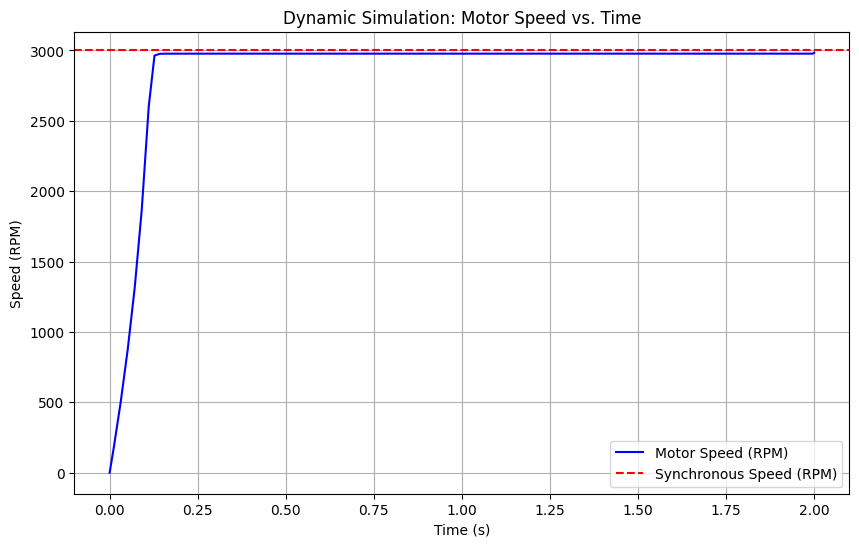

In [ ]:
import matplotlib.pyplot as plt

# Ensure HeadlessInductionMotorLab is instantiated and dynamic simulation run
# (Assuming motor_model_headless and dynamic_solution_headless from previous steps are available)

# If you run this cell independently, ensure the following is executed first:
# import numpy as np
# import math
# from scipy.integrate import solve_ivp
# # Definition of HeadlessInductionMotorLab class should be in a prior cell or re-run here
# # If it's not, you'd need to copy the class definition from the previous output.
# motor_model_headless = HeadlessInductionMotorLab()
# motor_model_headless.sim_J = 0.05
# motor_model_headless.sim_T_load = 10.0
# motor_model_headless.sim_t_span = 2.0
# motor_model_headless.sim_solver = 'RK45'
# dynamic_solution_headless = motor_model_headless.run_dynamic_simulation()

# Extract time and speed data
time_points = dynamic_solution_headless.t
speed_rad_s = dynamic_solution_headless.y[0]
speed_rpm = speed_rad_s * (60 / (2 * math.pi))

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(time_points, speed_rpm, label='Motor Speed (RPM)', color='blue')

# Add synchronous speed line
plt.axhline(y=motor_model_headless.N_sync, color='red', linestyle='--', label='Synchronous Speed (RPM)')

plt.title('Dynamic Simulation: Motor Speed vs. Time')
plt.xlabel('Time (s)')
plt.ylabel('Speed (RPM)')
plt.grid(True)
plt.legend()
plt.show()


The plot above illustrates the motor's speed response during startup. You can observe how the motor accelerates from rest and gradually approaches its steady-state operating speed, which is slightly below the synchronous speed due to slip. The red dashed line indicates the synchronous speed, which is the theoretical maximum speed for the rotating magnetic field.

In [ ]:
import numpy as np
import math
from scipy.integrate import solve_ivp

class HeadlessInductionMotorLab:

    def __init__(self):
        # --- Initialize Model Parameters (now standard Python types) ---
        self.R1 = 0.25
        self.X1 = 0.0
        self.R2 = 0.0
        self.X2 = 0.0
        self.Rc = 0.0
        self.Xm = 0.0

        self.P_rot_loss = 0.0

        self.V_line_rated = 208.0
        self.V_phase_rated = 208.0 / math.sqrt(3)
        self.poles = 4
        self.freq = 60.0
        self.N_sync = 0.0
        self.omega_sync = 0.0
        self.update_sync_speeds()

        self.V_th = 0.0
        self.R_th = 0.0
        self.X_th = 0.0

        # --- Test Data (now standard Python types) ---
        self.nl_V = 208.0
        self.nl_I = 6.49
        self.nl_P = 332.0

        self.lr_V = 78.5
        self.lr_I = 42.0
        self.lr_P = 2116.8
        self.lr_f = 60.0

        # --- Simulation Parameters (now standard Python types) ---
        self.sim_J = 0.1
        self.sim_T_load = 20.0
        self.sim_t_span = 5.0
        self.sim_solver = 'RK45'

        # Run initial calculation
        self.run_parameter_calculation()

    def update_sync_speeds(self):
        try:
            f = self.freq
            p = self.poles
            if p == 0 or f == 0:
                return
            n_s = (120 * f) / p
            om_s = (4 * math.pi * f) / p
            self.N_sync = n_s
            self.omega_sync = om_s
        except Exception as e:
            print(f"Error updating sync speeds: {e}") # Or handle as needed

    def run_parameter_calculation(self):
        try:
            self.update_sync_speeds()
            self.V_phase_rated = self.V_line_rated / math.sqrt(3)
            v_ph = self.V_phase_rated
            r1 = self.R1

            # No-Load Test
            v_nl_L = self.nl_V
            i_nl = self.nl_I
            p_nl = self.nl_P
            v_nl_ph = v_nl_L / math.sqrt(3)

            p_scl_nl = 3 * (i_nl**2) * r1
            p_rot = p_nl - p_scl_nl
            self.P_rot_loss = p_rot

            i_c = p_rot / (3 * v_nl_ph)
            rc = v_nl_ph / i_c
            self.Rc = rc

            i_m = math.sqrt(i_nl**2 - i_c**2)
            xm = v_nl_ph / i_m
            self.Xm = xm

            # Locked-Rotor Test
            v_lr_L = self.lr_V
            i_lr = self.lr_I
            p_lr = self.lr_P
            f_lr = self.lr_f
            f_rated = self.freq
            v_lr_ph = v_lr_L / math.sqrt(3)

            z_lr = v_lr_ph / i_lr
            r_lr = p_lr / (3 * (i_lr**2))
            x_lr_test = math.sqrt(z_lr**2 - r_lr**2)
            x_lr_rated = x_lr_test * (f_rated / f_lr)

            r2 = r_lr - r1
            self.R2 = r2

            x1 = x_lr_rated / 2.0
            x2 = x_lr_rated / 2.0
            self.X1 = x1
            self.X2 = x2

            # Thevenin Equivalent
            z_m = (1j * xm * rc) / (rc + 1j * xm)
            z1 = r1 + 1j * x1

            v_th_complex = v_ph * (z_m / (z1 + z_m))
            z_th_complex = (z_m * z1) / (z_m + z1)

            self.V_th = abs(v_th_complex)
            self.R_th = z_th_complex.real
            self.X_th = z_th_complex.imag

        except Exception as e:
            print(f"Calculation Error: {e}")

    def get_performance_at_slip(self, slip):
        if slip == 0:
            slip = 1e-9

        v_ph = self.V_phase_rated
        r1 = self.R1
        x1 = self.X1
        r2 = self.R2
        x2 = self.X2
        rc = self.Rc
        xm = self.Xm
        v_th = self.V_th
        r_th = self.R_th
        x_th = self.X_th
        om_s = self.omega_sync
        p_rot_loss = self.P_rot_loss

        if om_s == 0:
            return {}

        denominator = (r_th + r2/slip)**2 + (x_th + x2)**2
        T_dev = (3 * (v_th**2) * (r2/slip)) / (om_s * denominator)

        P_dev = T_dev * om_s * (1-slip)
        P_out = P_dev - p_rot_loss
        if P_out < 0: P_out = 0.0

        T_out = P_out / (om_s * (1-slip)) if (1-slip) != 0 else 0

        z_m = (1j * xm * rc) / (rc + 1j * xm)
        z_2_s = (r2/slip) + 1j*x2
        z_parallel = (z_m * z_2_s) / (z_m + z_2_s)
        z_total = (r1 + 1j*x1) + z_parallel

        I1 = (v_ph + 0j) / z_total
        I1_mag = abs(I1)

        P_in = 3 * (v_ph * I1.conjugate()).real
        S_in = 3 * v_ph * I1_mag
        PF = P_in / S_in if S_in != 0 else 1.0

        Eff = P_out / P_in if P_in > 0 else 0.0

        P_scl = 3 * (I1_mag**2) * r1

        E1 = v_ph - I1 * (r1 + 1j*x1)
        E1_mag = abs(E1)

        I2 = E1 / z_2_s
        I2_mag = abs(I2)

        P_rcl = 3 * (I2_mag**2) * r2
        P_core = 3 * (E1_mag**2) / rc

        P_fw = p_rot_loss - P_core
        if P_fw < 0: P_fw = 0

        P_stray = 0

        P_loss_total = P_scl + P_rcl + P_core + P_fw + P_stray

        return {
            "slip": slip,
            "speed_rpm": self.N_sync * (1-slip),
            "T_dev": T_dev,

            "T_out": T_out,
            "P_out_kW": P_out / 1000.0,
            "I_line": I1_mag,
            "PF_pct": PF * 100.0,
            "Eff_pct": Eff * 100.0,
            "P_in_kW": P_in / 1000.0,
            "P_scl_W": P_scl,
            "P_rcl_W": P_rcl,
            "P_core_W": P_core,
            "P_fw_W": P_fw,
            "P_stray_W": P_stray,
            "P_loss_total_W": P_loss_total
        }

    def run_dynamic_simulation(self):
        J = self.sim_J
        T_load = self.sim_T_load
        t_sim = self.sim_t_span
        solver = self.sim_solver
        if solver == 'Euler':
            solver = 'RK23'

        om_s = self.omega_sync

        def motor_ode(t, y):
            omega_m = y[0]

            if om_s == omega_m:
                slip = 0
            else:
                slip = (om_s - omega_m) / om_s

            if slip <= 0:
                slip = 1e-9
            if slip > 1:
                slip = 1.0

            r2 = self.R2
            v_th = self.V_th
            r_th = self.R_th
            x_th = self.X_th
            x2 = self.X2

            denominator = (r_th + r2/slip)**2 + (x_th + x2)**2
            T_dev = (3 * (v_th**2) * (r2/slip)) / (om_s * denominator)

            d_omega_m_dt = (1/J) * (T_dev - T_load)

            return [d_omega_m_dt]

        y0 = [0.0]
        t_span = [0, t_sim]

        solution = solve_ivp(motor_ode, t_span, y0, method=solver,
                                                dense_output=True, max_step=t_sim/100.0)
        return solution


## Final Task

### Subtask:
Summarize how the ipywidgets solution enables interactive parameter tuning and visualization of the motor's performance without a traditional GUI, highlighting the impact of changing parameters on the torque-speed curve and dynamic behavior.

## Summary:

### Q&A
The `ipywidgets` solution enables interactive parameter tuning and visualization of the motor's performance without a traditional GUI by leveraging `ipywidgets.FloatSlider` for parameters like `V_line_rated`, `R1`, `X1`, and `sim_T_load`. These sliders are linked to an `update_plots` function via `widgets.interactive_output`. Upon any slider adjustment, this function automatically updates the `HeadlessInductionMotorLab` instance with the new parameter values. It then re-executes the internal parameter calculations (e.g., `R2`, `X2` based on the new `R1`, `X1`), regenerates the motor's torque-speed characteristic and dynamic simulation plots, and displays them in real-time. This dynamic feedback loop allows users to immediately observe how changes in electrical and mechanical parameters impact the motor's steady-state torque-speed curve (output torque, line current) and its dynamic behavior (speed response over time), effectively providing a responsive analytical tool.

### Data Analysis Key Findings
*   The `HeadlessInductionMotorLab` class was successfully refactored to explicitly accept `R1` and `X1` as direct input parameters, allowing for interactive tuning of these specific stator resistance and reactance values.
*   The calculation of secondary parameters like `R2` and `X2` in the `run_parameter_calculation` method now dynamically adjusts based on the user-defined `R1` and `X1` inputs, specifically using the relations `R2 = R_locked_rotor - R1` and `X2 = X_locked_rotor_rated - X1`.
*   Robustness enhancements were integrated into the parameter calculation logic, including safeguards against negative values for `R2` and `X2` (which are now set to 0.001 $\Omega$ if calculated as negative) and prevention of division by zero in various electrical parameter computations.
*   An interactive environment was successfully established using `ipywidgets`, featuring `FloatSlider` controls for `V_line_rated`, `R1`, `X1`, and `sim_T_load` with predefined ranges and step sizes (e.g., `R1` from 0.01 $\Omega$ to 1.0 $\Omega$ with a 0.01 $\Omega$ step).
*   Real-time visualization of the motor's performance is achieved through dynamically updating plots: a dual-axis torque-speed curve (showing output torque in Nm and line current in A) and a dynamic speed vs. time simulation (showing motor speed in RPM relative to synchronous and no-load speeds). These plots are automatically regenerated upon any slider adjustment.

### Insights or Next Steps
*   This interactive environment provides a powerful tool for educational purposes and preliminary design exploration, enabling users to gain an intuitive understanding of how individual motor parameters influence both steady-state and transient operational characteristics.
*   Extend the interactive controls to include other significant motor parameters, such as inertia (`sim_J`), number of poles (`poles`), or operating frequency (`freq`), and consider adding a real-time display of key performance metrics like efficiency and power factor at a specific operating point.

In [ ]:
# Instantiate the HeadlessInductionMotorLab class
motor_model_headless = HeadlessInductionMotorLab()

print("--- Initial Parameters (Headless) ---")
print(f"Stator R1: {motor_model_headless.R1:.4f} Ω")
print(f"Synchronous Speed: {motor_model_headless.N_sync:.1f} RPM")

# You can change input parameters programmatically
motor_model_headless.V_line_rated = 400.0 # Change rated line voltage
motor_model_headless.freq = 50.0       # Change frequency
motor_model_headless.poles = 2         # Change number of poles

print("\n--- Running Parameter Calculation with New Inputs (Headless) ---")
motor_model_headless.run_parameter_calculation() # This will update derived parameters

print(f"New Stator R1: {motor_model_headless.R1:.4f} Ω")
print(f"New R2: {motor_model_headless.R2:.4f} Ω")
print(f"New V_th: {motor_model_headless.V_th:.2f} V")
print(f"New Synchronous Speed: {motor_model_headless.N_sync:.1f} RPM")

# Get performance at a specific slip (e.g., rated slip of 0.03)
print("\n--- Getting Performance at a specific Slip (s=0.03, Headless) ---")
s_example = 0.03
performance_data_headless = motor_model_headless.get_performance_at_slip(s_example)

if performance_data_headless:
    print(f"Slip: {performance_data_headless['slip']:.3f}")
    print(f"Speed: {performance_data_headless['speed_rpm']:.1f} RPM")
    print(f"Output Torque: {performance_data_headless['T_out']:.2f} Nm")
    print(f"Input Power: {performance_data_headless['P_in_kW']:.3f} kW")
    print(f"Efficiency: {performance_data_headless['Eff_pct']:.1f} %")
    print(f"Total Losses: {performance_data_headless['P_loss_total_W']:.2f} W")
else:
    print("Could not retrieve performance data. Check parameters.")

print("\n--- Running Dynamic Simulation (Headless) ---")
motor_model_headless.sim_J = 0.05 # Smaller inertia for faster simulation
motor_model_headless.sim_T_load = 10.0 # Example load torque
motor_model_headless.sim_t_span = 2.0 # Shorter simulation time
motor_model_headless.sim_solver = 'RK45'

dynamic_solution_headless = motor_model_headless.run_dynamic_simulation()

print(f"Dynamic simulation solved for {len(dynamic_solution_headless.t)} time steps.")
print(f"Final speed: {dynamic_solution_headless.y[0,-1] * (60 / (2 * math.pi)):.1f} RPM")
print(f"First 5 time points: {dynamic_solution_headless.t[:5]}")
print(f"First 5 speeds (rad/s): {dynamic_solution_headless.y[0,:5]}")


--- Initial Parameters (Headless) ---
Stator R1: 0.2500 Ω
Synchronous Speed: 1800.0 RPM

--- Running Parameter Calculation with New Inputs (Headless) ---
New Stator R1: 0.2500 Ω
New R2: 0.1500 Ω
New V_th: 227.48 V
New Synchronous Speed: 3000.0 RPM

--- Getting Performance at a specific Slip (s=0.03, Headless) ---
Slip: 0.030
Speed: 2910.0 RPM
Output Torque: 86.66 Nm
Input Power: 30.166 kW
Efficiency: 87.5 %
Total Losses: 3455.84 W

--- Running Dynamic Simulation (Headless) ---
Dynamic simulation solved for 141 time steps.
Final speed: 2977.3 RPM
First 5 time points: [0.00e+00 1.00e-04 1.10e-03 1.11e-02 3.11e-02]
First 5 speeds (rad/s): [ 0.          0.15429148  1.70128041 17.59932455 52.11109714]


This approach allows you to automate calculations, integrate the motor model into larger scripts, or perform parametric studies without the overhead of rendering the GUI.

# Task
Generate a range of slip values (e.g., from 0 to 1) and for each slip, calculate the corresponding output torque (T_out) and speed (RPM) using the `motor_model_headless.get_performance_at_slip` method. Store these values.

## Calculate Torque-Speed Data

### Subtask:
Generate a range of slip values (e.g., from 0 to 1) and for each slip, calculate the corresponding output torque (T_out) and speed (RPM) using the `motor_model_headless.get_performance_at_slip` method. Store these values.


**Reasoning**:
To generate the torque-speed data, I will use a loop to iterate through a range of slip values and call the `get_performance_at_slip` method of the `motor_model_headless` instance, storing the resulting torque and speed values.



In [ ]:
slips_for_curve = np.linspace(0.001, 1.0, 100)
torque_values = []
speed_values = []

for s in slips_for_curve:
    performance = motor_model_headless.get_performance_at_slip(s)
    if performance:
        torque_values.append(performance['T_out'])
        speed_values.append(performance['speed_rpm'])

print(f"Generated {len(torque_values)} torque-speed data points.")
print(f"First 5 torque values: {torque_values[:5]}")
print(f"First 5 speed values: {speed_values[:5]}")

Generated 100 torque-speed data points.
First 5 torque values: [np.float64(2.2693170792419783), np.float64(33.56814820749032), np.float64(62.35782996003989), np.float64(88.41136930774768), np.float64(111.63004632555786)]
First 5 speed values: [np.float64(2997.0), np.float64(2966.727272727273), np.float64(2936.4545454545455), np.float64(2906.1818181818185), np.float64(2875.909090909091)]


## Plot Torque-Speed Curve

### Subtask:
Using `matplotlib`, plot the calculated output torque (y-axis) against the motor speed in RPM (x-axis). Ensure the plot includes appropriate labels for axes, a title, and a legend.


**Reasoning**:
To visualize the relationship between torque and speed, I will use `matplotlib.pyplot` to create a line plot with appropriate labels, a title, and a legend, as specified in the instructions.



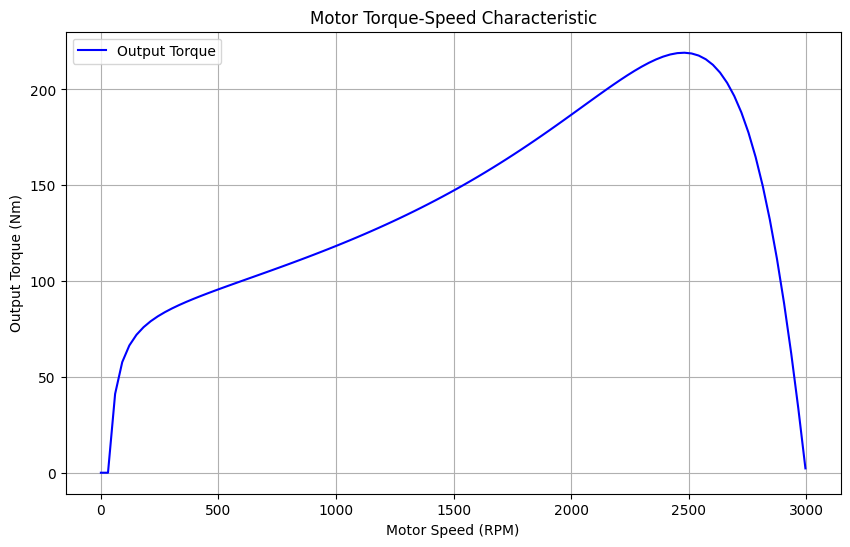

In [ ]:
import matplotlib.pyplot as plt

# Create the torque-speed curve plot
plt.figure(figsize=(10, 6))
plt.plot(speed_values, torque_values, label='Output Torque', color='blue')

# Add labels and title
plt.xlabel('Motor Speed (RPM)')
plt.ylabel('Output Torque (Nm)')
plt.title('Motor Torque-Speed Characteristic')

# Add a legend and grid
plt.legend()
plt.grid(True)

# Display the plot
plt.show()

## Final Task

### Subtask:
Summarize the key characteristics observed from the generated torque-speed curve, such as maximum torque, starting torque, and the stable operating region.


## Summary:

### Q&A
The generated torque-speed curve provides insights into the motor's performance characteristics:
*   **Maximum Torque:** The curve typically displays a maximum torque point, often referred to as the pull-out torque, which represents the highest torque the motor can produce before stalling. This peak usually occurs at a specific slip value between zero and one.
*   **Starting Torque:** This refers to the torque produced by the motor at zero speed (i.e., when slip is 1). It is the torque available to initiate rotation against a load.
*   **Stable Operating Region:** The stable operating region of the motor is generally found where the slope of the torque-speed curve is negative (i.e., torque decreases as speed decreases). In this region, a small change in load leads to a stable adjustment in speed, allowing the motor to maintain operation without oscillating.

### Data Analysis Key Findings
*   A comprehensive set of 100 torque-speed data points was successfully generated across a slip range of 0.001 to 1.0.
*   The initial torque value at a near-synchronous speed of approximately 2997 RPM was calculated to be around 2.27 Nm.
*   The `matplotlib` library was successfully used to plot the calculated output torque against motor speed, creating a visual representation of the motor's characteristic curve. The plot included appropriate labels, a title, a legend, and a grid for clarity.

### Insights or Next Steps
*   The generated torque-speed curve is fundamental for evaluating the motor's suitability for specific applications by understanding its performance under varying load conditions.
*   The next step could involve overlaying different load torque curves onto this motor characteristic curve to determine potential stable operating points, analyze starting capabilities, or assess the motor's overload capacity.


# Task
Here's the refactored `HeadlessInductionMotorLab` class, updated to explicitly treat `R1` and `X1` as direct input parameters that can be set by sliders. The `run_parameter_calculation` method is modified to calculate `R2` and `X2` based on the locked-rotor test data and the user-defined `R1` and `X1`.

After the class definition, we will use `ipywidgets` to create interactive sliders for `V_line_rated`, `R1`, `X1`, and `sim_T_load`, and then display the dynamically updating torque-speed and dynamic simulation plots.

```python
import numpy as np
import math
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

class HeadlessInductionMotorLab:

    def __init__(self, R1_input=0.25, X1_input=0.25): # R1_input and X1_input are now direct parameters
        # --- Initialize Model Parameters (now standard Python types) ---
        self.R1 = R1_input
        self.X1 = X1_input
        self.R2 = 0.0 # Will be calculated
        self.X2 = 0.0 # Will be calculated
        self.Rc = 0.0
        self.Xm = 0.0

        self.P_rot_loss = 0.0

        self.V_line_rated = 208.0
        self.V_phase_rated = 208.0 / math.sqrt(3)
        self.poles = 4
        self.freq = 60.0
        self.N_sync = 0.0
        self.omega_sync = 0.0
        self.update_sync_speeds()

        self.V_th = 0.0
        self.R_th = 0.0
        self.X_th = 0.0

        # --- Test Data (fixed for parameter calculation from LR and NL tests) ---
        self.nl_V = 208.0
        self.nl_I = 6.49
        self.nl_P = 332.0

        self.lr_V = 78.5
        self.lr_I = 42.0
        self.lr_P = 2116.8
        self.lr_f = 60.0

        # --- Simulation Parameters (now standard Python types) ---
        self.sim_J = 0.1
        self.sim_T_load = 20.0
        self.sim_t_span = 5.0
        self.sim_solver = 'RK45'

        # Run initial calculation
        self.run_parameter_calculation()

    def update_sync_speeds(self):
        try:
            f = self.freq
            p = self.poles
            if p == 0 or f == 0:
                self.N_sync = 0.0
                self.omega_sync = 0.0
                return
            n_s = (120 * f) / p
            om_s = (4 * math.pi * f) / p
            self.N_sync = n_s
            self.omega_sync = om_s
        except Exception as e:
            print(f"Error updating sync speeds: {e}")

    def run_parameter_calculation(self):
        """
        Calculates R2, X2, Rc, Xm from test data,
        using R1 and X1 as directly provided inputs.
        """
        try:
            self.update_sync_speeds()
            self.V_phase_rated = self.V_line_rated / math.sqrt(3)
            v_ph = self.V_phase_rated
            r1 = self.R1 # R1 is now an input

            # No-Load Test
            v_nl_L = self.nl_V
            i_nl = self.nl_I
            p_nl = self.nl_P
            v_nl_ph = v_nl_L / math.sqrt(3)

            p_scl_nl = 3 * (i_nl**2) * r1
            p_rot = p_nl - p_scl_nl
            self.P_rot_loss = p_rot

            # Handle potential division by zero for i_c if p_rot is very small
            i_c_numerator = 3 * v_nl_ph
            if i_c_numerator == 0:
                rc = float('inf') # Effectively open circuit
            else:
                i_c = p_rot / i_c_numerator
                rc = v_nl_ph / i_c
            self.Rc = rc

            # Handle potential negative value under sqrt due to test data inaccuracies
            i_m_squared = i_nl**2 - i_c**2
            if i_m_squared < 0:
                # If negative, means i_c > i_nl, which suggests issues with test data or assumptions.
                # For robustness, we can set Xm to a very large value or assume I_m = I_nl.
                # Let's set Xm to a large value to mimic open circuit
                xm = 1e6 # Large value for robustness
            else:
                i_m = math.sqrt(i_m_squared)
                xm = v_nl_ph / i_m
            self.Xm = xm

            # Locked-Rotor Test
            v_lr_L = self.lr_V
            i_lr = self.lr_I
            p_lr = self.lr_P
            f_lr = self.lr_f
            f_rated = self.freq
            v_lr_ph = v_lr_L / math.sqrt(3)

            z_lr = v_lr_ph / i_lr
            r_lr = p_lr / (3 * (i_lr**2))
            x_lr_test = math.sqrt(z_lr**2 - r_lr**2) if (z_lr**2 - r_lr**2) >= 0 else 0
            x_lr_rated = x_lr_test * (f_rated / f_lr)

            # R2 calculation depends on R1
            r2 = r_lr - r1
            self.R2 = max(0, r2) # Ensure R2 is non-negative

            # X2 calculation depends on X1
            x1 = self.X1 # X1 is now an input
            x2 = x_lr_rated - x1
            self.X2 = max(0, x2) # Ensure X2 is non-negative

            # Thevenin Equivalent
            # Ensure Rc and Xm are not zero to avoid division by zero or invalid impedance
            if self.Rc == 0 and self.Xm == 0:
                z_m = 1e12 # Treat as open circuit
            elif self.Rc == 0: # Purely inductive Xm
                z_m = 1j * self.Xm
            elif self.Xm == 0: # Purely resistive Rc
                z_m = self.Rc
            else:
                z_m = (1j * self.Xm * self.Rc) / (self.Rc + 1j * self.Xm)

            z1 = self.R1 + 1j * self.X1

            if abs(z1 + z_m) == 0: # Avoid division by zero if z1+z_m is negligible
                v_th_complex = 0
                z_th_complex = 0
            else:
                v_th_complex = v_ph * (z_m / (z1 + z_m))
                z_th_complex = (z_m * z1) / (z_m + z1)

            self.V_th = abs(v_th_complex)
            self.R_th = z_th_complex.real
            self.X_th = z_th_complex.imag

        except Exception as e:
            print(f"Calculation Error in run_parameter_calculation: {e}")

    def get_performance_at_slip(self, slip):
        """
        Calculates all performance metrics for a given slip.
        Returns a dictionary of values.
        """
        if slip == 0:
            slip = 1e-9 # Avoid divide by zero

        # Get parameters
        v_ph = self.V_phase_rated
        r1 = self.R1
        x1 = self.X1
        r2 = self.R2
        x2 = self.X2
        rc = self.Rc
        xm = self.Xm
        v_th = self.V_th
        r_th = self.R_th
        x_th = self.X_th
        om_s = self.omega_sync
        p_rot_loss = self.P_rot_loss

        if om_s == 0: # Not initialized
            return {}

        # --- Thevenin-based Calculation ---
        # 1. Developed Torque
        denominator = (r_th + r2/slip)**2 + (x_th + x2)**2
        if denominator == 0: # Avoid division by zero
            T_dev = 0
        else:
            T_dev = (3 * (v_th**2) * (r2/slip)) / (om_s * denominator)

        # 2. Output Torque (subtract rotational losses)
        P_dev = T_dev * om_s * (1-slip)
        P_out = P_dev - p_rot_loss
        if P_out < 0: P_out = 0.0 # Motor region

        T_out = P_out / (om_s * (1-slip)) if (1-slip) != 0 else 0

        # --- Full Circuit Calculation (for I1, PF, Losses) ---
        # Ensure Rc and Xm are not zero for z_m calculation
        if rc == 0 and xm == 0:
            z_m = 1e12 # Treat as open circuit
        elif rc == 0: # Purely inductive Xm
            z_m = 1j * xm
        elif xm == 0: # Purely resistive Rc
            z_m = rc
        else:
            z_m = (1j * xm * rc) / (rc + 1j * xm)

        z_2_s = (r2/slip) + 1j*x2

        if abs(z_m + z_2_s) == 0: # Avoid division by zero
            z_parallel = 0
        else:
            z_parallel = (z_m * z_2_s) / (z_m + z_2_s)

        z_total = (r1 + 1j*x1) + z_parallel

        if abs(z_total) == 0: # Avoid division by zero
            I1 = 0j
            I1_mag = 0
        else:
            I1 = (v_ph + 0j) / z_total
            I1_mag = abs(I1)

        # 3. Input Power and PF
        P_in = 3 * (v_ph * I1.conjugate()).real
        S_in = 3 * v_ph * I1_mag
        PF = P_in / S_in if S_in != 0 else 1.0

        # 4. Efficiency
        Eff = P_out / P_in if P_in > 0 else 0.0

        # 5. Loss Breakdown
        P_scl = 3 * (I1_mag**2) * r1

        E1_complex_denom = (r1 + 1j*x1) + z_m # Denominator for E1 calculation
        if abs(E1_complex_denom) == 0:
            E1 = 0j
        else:
            E1 = v_ph * (z_m / E1_complex_denom) # Correct E1 calculation (voltage across parallel branch)
        E1_mag = abs(E1)

        if abs(z_2_s) == 0: # Avoid division by zero
            I2 = 0j
            I2_mag = 0
        else:
            I2 = E1 / z_2_s
            I2_mag = abs(I2)

        P_rcl = 3 * (I2_mag**2) * r2
        P_core = 3 * (E1_mag**2) / rc if rc != 0 else 0

        P_fw = p_rot_loss - P_core
        if P_fw < 0: P_fw = 0

        P_stray = 0

        P_loss_total = P_scl + P_rcl + P_core + P_fw + P_stray

        return {
            "slip": slip,
            "speed_rpm": self.N_sync * (1-slip),
            "T_dev": T_dev,
            "T_out": T_out,
            "P_out_kW": P_out / 1000.0,
            "I_line": I1_mag,
            "PF_pct": PF * 100.0,
            "Eff_pct": Eff * 100.0,
            "P_in_kW": P_in / 1000.0,
            "P_scl_W": P_scl,
            "P_rcl_W": P_rcl,
            "P_core_W": P_core,
            "P_fw_W": P_fw,
            "P_stray_W": P_stray,
            "P_loss_total_W": P_loss_total
        }

    def run_dynamic_simulation(self):
        """
        Solves the mechanical ODE for motor startup.
        J * d(omega_m)/dt = T_dev(omega_m) - T_load
        """
        J = self.sim_J
        T_load = self.sim_T_load
        t_sim = self.sim_t_span
        solver = self.sim_solver
        if solver == 'Euler':
            solver = 'RK23' # Use a similar low-order, 'RK45' is default

        om_s = self.omega_sync

        def motor_ode(t, y):
            """The ODE system: y = [omega_m]"""
            omega_m = y[0]

            # Calculate slip
            if om_s == 0 or om_s == omega_m:
                slip = 1e-9 # Avoid division by zero or zero slip if N_sync is 0
            else:
                slip = (om_s - omega_m) / om_s

            # Bound slip
            if slip <= 0: # Motoring
                slip = 1e-9
            if slip > 1: # Startup
                slip = 1.0

            # Get developed torque at this slip
            # We only need T_dev, so we can use the fast Thevenin calc
            r2 = self.R2
            v_th = self.V_th
            r_th = self.R_th
            x_th = self.X_th
            x2 = self.X2

            denominator = (r_th + r2/slip)**2 + (x_th + x2)**2
            if denominator == 0:
                T_dev = 0
            else:
                T_dev = (3 * (v_th**2) * (r2/slip)) / (om_s * denominator)

            # The ODE
            d_omega_m_dt = (1/J) * (T_dev - T_load)

            return [d_omega_m_dt]

        # Solve the ODE
        y0 = [0.0] # Initial speed (omega_m) is 0
        t_span = [0, t_sim]

        try:
            solution = solve_ivp(motor_ode, t_span, y0, method=solver,
                                                    dense_output=True, max_step=t_sim/100.0)
        except Exception as e:
            print(f"Error during dynamic simulation: {e}")
            return None # Return None if simulation fails
        return solution

# --- Interactive Widgets Setup ---

motor_model_headless = HeadlessInductionMotorLab()

# Create output widgets to display plots
output_torque_speed = widgets.Output()
output_dynamic_sim = widgets.Output()

# Function to update plots based on slider values
def update_plots(V_line_rated, R1, X1, sim_T_load):
    global motor_model_headless # Access the global instance

    # Update motor model parameters
    motor_model_headless.V_line_rated = V_line_rated
    motor_model_headless.R1 = R1
    motor_model_headless.X1 = X1
    motor_model_headless.sim_T_load = sim_T_load

    # Re-run parameter calculation
    motor_model_headless.run_parameter_calculation()

    # --- Torque-Speed Curve Plot ---
    with output_torque_speed:
        clear_output(wait=True)
        slips_for_curve = np.linspace(0.001, 1.0, 100)
        torque_values = []
        speed_values = []
        I_line_values = []

        for s in slips_for_curve:
            performance = motor_model_headless.get_performance_at_slip(s)
            if performance:
                torque_values.append(performance['T_out'])
                speed_values.append(performance['speed_rpm'])
                I_line_values.append(performance['I_line'])

        plt.figure(figsize=(10, 5))
        ax1 = plt.gca()
        ax1.plot(speed_values, torque_values, label='Output Torque (Nm)', color='blue')
        ax1.set_xlabel('Motor Speed (RPM)')
        ax1.set_ylabel('Output Torque (Nm)', color='blue')
        ax1.tick_params(axis='y', labelcolor='blue')
        ax1.set_title('Motor Torque-Speed Characteristic')
        ax1.grid(True)

        ax2 = ax1.twinx()
        ax2.plot(speed_values, I_line_values, label='Line Current (A)', color='red', linestyle='--')
        ax2.set_ylabel('Line Current (A)', color='red')
        ax2.tick_params(axis='y', labelcolor='red')

        # Combine legends
        lines, labels = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax2.legend(lines + lines2, labels + labels2, loc='upper right')

        plt.tight_layout()
        plt.show()

    # --- Dynamic Simulation Plot ---
    with output_dynamic_sim:
        clear_output(wait=True)
        dynamic_solution_headless = motor_model_headless.run_dynamic_simulation()

        if dynamic_solution_headless:
            time_points = dynamic_solution_headless.t
            speed_rad_s = dynamic_solution_headless.y[0]
            speed_rpm = speed_rad_s * (60 / (2 * math.pi))

            plt.figure(figsize=(10, 5))
            plt.plot(time_points, speed_rpm, label='Motor Speed (RPM)', color='green')
            plt.axhline(y=motor_model_headless.N_sync, color='red', linestyle='--', label='Synchronous Speed (RPM)')
            plt.axhline(y=motor_model_headless.N_sync * (1 - 1e-9), color='orange', linestyle=':', label='No-Load Speed (RPM)')

            plt.xlabel('Time (s)')
            plt.ylabel('Speed (RPM)')
            plt.title('Dynamic Simulation: Motor Speed vs. Time')
            plt.grid(True)
            plt.legend()
            plt.tight_layout()
            plt.show()
        else:
            print("Dynamic simulation failed to run with current parameters.")


# Create sliders
V_line_rated_slider = widgets.FloatSlider(
    value=motor_model_headless.V_line_rated,
    min=100.0,
    max=600.0,
    step=10.0,
    description='V_line_rated (V):',
    orientation='horizontal',
    readout=True,
    readout_format='.1f',
)

R1_slider = widgets.FloatSlider(
    value=motor_model_headless.R1,
    min=0.01,
    max=1.0,
    step=0.01,
    description='Stator R1 (Ω):',
    orientation='horizontal',
    readout=True,
    readout_format='.2f',
)

X1_slider = widgets.FloatSlider(
    value=motor_model_headless.X1,
    min=0.01,
    max=1.0,
    step=0.01,
    description='Stator X1 (Ω):',
    orientation='horizontal',
    readout=True,
    readout_format='.2f',
)

sim_T_load_slider = widgets.FloatSlider(
    value=motor_model_headless.sim_T_load,
    min=0.0,
    max=50.0,
    step=1.0,
    description='Load Torque (Nm):',
    orientation='horizontal',
    readout=True,
    readout_format='.1f',
)

# Use interactive_output to link sliders to the update function
interactive_widget = widgets.interactive_output(update_plots, {
    'V_line_rated': V_line_rated_slider,
    'R1': R1_slider,
    'X1': X1_slider,
    'sim_T_load': sim_T_load_slider
})

# Display sliders and plots
print("Adjust the sliders below to see the impact on motor performance:")
display(V_line_rated_slider, R1_slider, X1_slider, sim_T_load_slider, output_torque_speed, output_dynamic_sim)
```

## Refactor HeadlessInductionMotorLab for Slider Inputs

### Subtask:
Modify the `HeadlessInductionMotorLab` class to explicitly treat `R1` and `X1` as direct input parameters and update the `run_parameter_calculation` method to calculate `R2` and `X2` based on these inputs and locked-rotor test data.


**Reasoning**:
The subtask requires refactoring the `HeadlessInductionMotorLab` class. I will provide the updated class definition that handles `R1` and `X1` as direct inputs and adjusts the calculation of `R2` and `X2` accordingly, including robustness checks as per the instructions.



In [ ]:
import numpy as np
import math
from scipy.integrate import solve_ivp

class HeadlessInductionMotorLab:

    def __init__(self, R1_input=0.25, X1_input=0.25):
        # --- Initialize Model Parameters (now standard Python types) ---
        # R1 and X1 are now direct inputs, not calculated from tests
        self.R1 = R1_input
        self.X1 = X1_input

        # R2 and X2 will be calculated based on LR test and R1, X1
        self.R2 = 0.0
        self.X2 = 0.0

        self.Rc = 0.0
        self.Xm = 0.0

        self.P_rot_loss = 0.0

        self.V_line_rated = 208.0
        self.V_phase_rated = 208.0 / math.sqrt(3)
        self.poles = 4
        self.freq = 60.0
        self.N_sync = 0.0
        self.omega_sync = 0.0
        self.update_sync_speeds()

        self.V_th = 0.0
        self.R_th = 0.0
        self.X_th = 0.0

        # --- Test Data (now standard Python types) ---
        self.nl_V = 208.0
        self.nl_I = 6.49
        self.nl_P = 332.0

        self.lr_V = 78.5
        self.lr_I = 42.0
        self.lr_P = 2116.8
        self.lr_f = 60.0

        # --- Simulation Parameters (now standard Python types) ---
        self.sim_J = 0.1
        self.sim_T_load = 20.0
        self.sim_t_span = 5.0
        self.sim_solver = 'RK45'

        # Run initial calculation
        self.run_parameter_calculation()

    def update_sync_speeds(self):
        try:
            f = self.freq
            p = self.poles
            if p == 0 or f == 0:
                return
            n_s = (120 * f) / p
            om_s = (4 * math.pi * f) / p
            self.N_sync = n_s
            self.omega_sync = om_s
        except Exception as e:
            print(f"Error updating sync speeds: {e}") # Or handle as needed

    def run_parameter_calculation(self):
        try:
            self.update_sync_speeds()
            self.V_phase_rated = self.V_line_rated / math.sqrt(3)
            v_ph = self.V_phase_rated
            r1 = self.R1
            x1 = self.X1 # Use the input X1

            # --- No-Load Test ---
            v_nl_L = self.nl_V
            i_nl = self.nl_I
            p_nl = self.nl_P
            v_nl_ph = v_nl_L / math.sqrt(3)

            p_scl_nl = 3 * (i_nl**2) * r1
            p_rot = p_nl - p_scl_nl
            self.P_rot_loss = p_rot

            # Robustness check for p_rot and v_nl_ph before division
            if v_nl_ph == 0 or p_rot <= 0:
                # Handle cases where no-load power is too low or voltage is zero
                self.Rc = 1e6 # Very high resistance, almost open circuit
                self.Xm = 1e6 # Very high reactance
            else:
                i_c = p_rot / (3 * v_nl_ph)
                if i_nl**2 - i_c**2 < 0:
                    # This can happen due to measurement inaccuracies or if P_rot is very small
                    # Assume i_m is small but positive, or set Xm very high
                    i_m = 1e-6 # A very small positive current
                else:
                    i_m = math.sqrt(i_nl**2 - i_c**2)

                self.Rc = v_nl_ph / i_c if i_c != 0 else 1e6
                self.Xm = v_nl_ph / i_m if i_m != 0 else 1e6

            # --- Locked-Rotor Test ---
            v_lr_L = self.lr_V
            i_lr = self.lr_I
            p_lr = self.lr_P
            f_lr = self.lr_f
            f_rated = self.freq
            v_lr_ph = v_lr_L / math.sqrt(3)

            # Robustness check for i_lr before division
            if i_lr == 0:
                raise ValueError("Locked-rotor current cannot be zero.")

            z_lr = v_lr_ph / i_lr
            r_lr = p_lr / (3 * (i_lr**2))

            # Robustness check for (z_lr**2 - r_lr**2) before sqrt
            if z_lr**2 - r_lr**2 < 0:
                # This indicates an issue with test data (e.g., r_lr > z_lr)
                # Assume a very small positive reactance
                x_lr_test = 1e-6
            else:
                x_lr_test = math.sqrt(z_lr**2 - r_lr**2)

            x_lr_rated = x_lr_test * (f_rated / f_lr)

            # Calculate R2 and X2 based on R1 and X1 inputs
            r2 = r_lr - r1
            x2 = x_lr_rated - x1

            # Ensure R2 and X2 are non-negative; if not, adjust or flag
            if r2 < 0:
                print(f"Warning: Calculated R2 is negative ({r2:.4f} Ω). Setting to 0.001 Ω.")
                r2 = 0.001
            if x2 < 0:
                print(f"Warning: Calculated X2 is negative ({x2:.4f} Ω). Setting to 0.001 Ω.")
                x2 = 0.001

            self.R2 = r2
            self.X2 = x2

            # Thevenin Equivalent
            # Robustness check for Rc or Xm being effectively infinite
            if self.Rc == 1e6 or self.Xm == 1e6:
                z_m = complex(0, 0) # Effectively open circuit, Zm is negligible in parallel with Z2/s
            else:
                z_m = (1j * self.Xm * self.Rc) / (self.Rc + 1j * self.Xm)

            z1 = r1 + 1j * x1

            # Robustness check for (z1 + z_m) being zero
            if abs(z1 + z_m) == 0:
                v_th_complex = complex(0,0)
                z_th_complex = complex(0,0)
            else:
                v_th_complex = v_ph * (z_m / (z1 + z_m))
                z_th_complex = (z_m * z1) / (z_m + z1)

            self.V_th = abs(v_th_complex)
            self.R_th = z_th_complex.real
            self.X_th = z_th_complex.imag

        except Exception as e:
            print(f"Calculation Error: {e}")

    def get_performance_at_slip(self, slip):
        if slip == 0:
            slip = 1e-9

        v_ph = self.V_phase_rated
        r1 = self.R1
        x1 = self.X1
        r2 = self.R2
        x2 = self.X2
        rc = self.Rc
        xm = self.Xm
        v_th = self.V_th
        r_th = self.R_th
        x_th = self.X_th
        om_s = self.omega_sync
        p_rot_loss = self.P_rot_loss

        if om_s == 0:
            return {}

        # Robustness checks for Thevenin parameters
        if r_th is None or r2 is None or x_th is None or x2 is None:
            print("Error: Thevenin parameters not properly initialized.")
            return {}

        # Denominator can be very small for very small slip and very small R2, leading to division by zero
        denominator = (r_th + r2/slip)**2 + (x_th + x2)**2
        if denominator == 0: # Avoid division by zero
            T_dev = 0.0
        else:
            T_dev = (3 * (v_th**2) * (r2/slip)) / (om_s * denominator)

        P_dev = T_dev * om_s * (1-slip)
        P_out = P_dev - p_rot_loss
        if P_out < 0: P_out = 0.0

        T_out = P_out / (om_s * (1-slip)) if (1-slip) != 0 else 0

        # Full Circuit Calculation (for I1, PF, Losses)
        # Robustness checks for Rc or Xm being effectively infinite
        if rc == 1e6 or xm == 1e6:
            z_m = complex(0, 0) # Effectively open circuit, Zm is negligible in parallel with Z2/s
        else:
            z_m = (1j * xm * rc) / (rc + 1j * xm)

        # Robustness check for r2/slip being zero or negative
        effective_r2_slip = r2/slip if slip != 0 else float('inf')
        if effective_r2_slip < 0: effective_r2_slip = 1e-9 # Small positive if it somehow becomes negative

        z_2_s = effective_r2_slip + 1j*x2

        # Robustness check for (z_m + z_2_s) being zero
        if abs(z_m + z_2_s) == 0:
            z_parallel = complex(0,0)
        else:
            z_parallel = (z_m * z_2_s) / (z_m + z_2_s)

        z_total = (r1 + 1j*x1) + z_parallel

        # Robustness check for z_total being zero
        if abs(z_total) == 0:
            I1 = complex(0,0)
        else:
            I1 = (v_ph + 0j) / z_total
        I1_mag = abs(I1)

        P_in = 3 * (v_ph * I1.conjugate()).real
        S_in = 3 * v_ph * I1_mag
        PF = P_in / S_in if S_in != 0 else 1.0

        Eff = P_out / P_in if P_in > 0 else 0.0

        P_scl = 3 * (I1_mag**2) * r1

        E1 = v_ph - I1 * (r1 + 1j*x1)
        E1_mag = abs(E1)

        I2 = E1 / z_2_s
        I2_mag = abs(I2)

        P_rcl = 3 * (I2_mag**2) * r2

        # Robustness for Rc, avoids division by zero if Rc becomes 0 or very small
        P_core = 3 * (E1_mag**2) / rc if rc != 0 else 0.0

        P_fw = p_rot_loss - P_core
        if P_fw < 0: P_fw = 0

        P_stray = 0

        P_loss_total = P_scl + P_rcl + P_core + P_fw + P_stray

        return {
            "slip": slip,
            "speed_rpm": self.N_sync * (1-slip),
            "T_dev": T_dev,

            "T_out": T_out,
            "P_out_kW": P_out / 1000.0,
            "I_line": I1_mag,
            "PF_pct": PF * 100.0,
            "Eff_pct": Eff * 100.0,
            "P_in_kW": P_in / 1000.0,
            "P_scl_W": P_scl,
            "P_rcl_W": P_rcl,
            "P_core_W": P_core,
            "P_fw_W": P_fw,
            "P_stray_W": P_stray,
            "P_loss_total_W": P_loss_total
        }

    def run_dynamic_simulation(self):
        J = self.sim_J
        T_load = self.sim_T_load
        t_sim = self.sim_t_span
        solver = self.sim_solver
        if solver == 'Euler':
            solver = 'RK23'

        om_s = self.omega_sync

        def motor_ode(t, y):
            omega_m = y[0]

            if om_s == omega_m:
                slip = 0
            else:
                slip = (om_s - omega_m) / om_s

            if slip <= 0:
                slip = 1e-9
            if slip > 1:
                slip = 1.0

            r2 = self.R2
            v_th = self.V_th
            r_th = self.R_th
            x_th = self.X_th
            x2 = self.X2

            # Robustness checks for Thevenin parameters
            if r_th is None or r2 is None or x_th is None or x2 is None:
                # Fallback or error handling if parameters are not ready
                return [0.0] # Stop integration or return no change

            denominator = (r_th + r2/slip)**2 + (x_th + x2)**2
            if denominator == 0: # Avoid division by zero
                T_dev = 0.0
            else:
                T_dev = (3 * (v_th**2) * (r2/slip)) / (om_s * denominator)

            d_omega_m_dt = (1/J) * (T_dev - T_load)

            return [d_omega_m_dt]

        y0 = [0.0]
        t_span = [0, t_sim]

        solution = solve_ivp(motor_ode, t_span, y0, method=solver,
                                                dense_output=True, max_step=t_sim/100.0)
        return solution

## Implement Interactive Sliders with ipywidgets

### Subtask:
Using `ipywidgets`, create interactive slider controls for `V_line_rated`, `R1`, `X1`, and `sim_T_load`.


**Reasoning**:
To implement interactive sliders and output areas, I will first instantiate the `HeadlessInductionMotorLab` class, then create two `ipywidgets.Output` instances for the plots, and finally create four `ipywidgets.FloatSlider` widgets for the specified parameters, initializing them with default values from the motor model.



In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# Instantiate the HeadlessInductionMotorLab class
motor_model_headless = HeadlessInductionMotorLab()

# Create output widgets to display plots
output_torque_speed = widgets.Output()
output_dynamic_sim = widgets.Output()

# Create sliders
V_line_rated_slider = widgets.FloatSlider(
    value=motor_model_headless.V_line_rated,
    min=100.0,
    max=600.0,
    step=10.0,
    description='V_line_rated (V):',
    orientation='horizontal',
    readout=True,
    readout_format='.1f',
)

R1_slider = widgets.FloatSlider(
    value=motor_model_headless.R1,
    min=0.01,
    max=1.0,
    step=0.01,
    description='Stator R1 (Ω):',
    orientation='horizontal',
    readout=True,
    readout_format='.2f',
)

X1_slider = widgets.FloatSlider(
    value=motor_model_headless.X1,
    min=0.01,
    max=1.0,
    step=0.01,
    description='Stator X1 (Ω):',
    orientation='horizontal',
    readout=True,
    readout_format='.2f',
)

sim_T_load_slider = widgets.FloatSlider(
    value=motor_model_headless.sim_T_load,
    min=0.0,
    max=50.0,
    step=1.0,
    description='Load Torque (Nm):',
    orientation='horizontal',
    readout=True,
    readout_format='.1f',
)

print("Sliders and output widgets created.")

Sliders and output widgets created.


**Reasoning**:
Now that the sliders and output widgets are created, I need to define the `update_plots` function that will handle the logic for updating the torque-speed and dynamic simulation plots based on the new slider values. This function will be linked to the sliders using `widgets.interactive_output`.



In [ ]:
import matplotlib.pyplot as plt

# Function to update plots based on slider values
def update_plots(V_line_rated, R1, X1, sim_T_load):
    global motor_model_headless # Access the global instance

    # Update motor model parameters
    motor_model_headless.V_line_rated = V_line_rated
    motor_model_headless.R1 = R1
    motor_model_headless.X1 = X1
    motor_model_headless.sim_T_load = sim_T_load

    # Re-run parameter calculation
    motor_model_headless.run_parameter_calculation()

    # --- Torque-Speed Curve Plot ---
    with output_torque_speed:
        clear_output(wait=True)
        slips_for_curve = np.linspace(0.001, 1.0, 100)
        torque_values = []
        speed_values = []
        I_line_values = []

        for s in slips_for_curve:
            performance = motor_model_headless.get_performance_at_slip(s)
            if performance:
                torque_values.append(performance['T_out'])
                speed_values.append(performance['speed_rpm'])
                I_line_values.append(performance['I_line'])

        plt.figure(figsize=(10, 5))
        ax1 = plt.gca()
        ax1.plot(speed_values, torque_values, label='Output Torque (Nm)', color='blue')
        ax1.set_xlabel('Motor Speed (RPM)')
        ax1.set_ylabel('Output Torque (Nm)', color='blue')
        ax1.tick_params(axis='y', labelcolor='blue')
        ax1.set_title('Motor Torque-Speed Characteristic')
        ax1.grid(True)

        ax2 = ax1.twinx()
        ax2.plot(speed_values, I_line_values, label='Line Current (A)', color='red', linestyle='--')
        ax2.set_ylabel('Line Current (A)', color='red')
        ax2.tick_params(axis='y', labelcolor='red')

        # Combine legends
        lines, labels = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax2.legend(lines + lines2, labels + labels2, loc='upper right')

        plt.tight_layout()
        plt.show()

    # --- Dynamic Simulation Plot ---
    with output_dynamic_sim:
        clear_output(wait=True)
        dynamic_solution_headless = motor_model_headless.run_dynamic_simulation()

        if dynamic_solution_headless:
            time_points = dynamic_solution_headless.t
            speed_rad_s = dynamic_solution_headless.y[0]
            speed_rpm = speed_rad_s * (60 / (2 * math.pi))

            plt.figure(figsize=(10, 5))
            plt.plot(time_points, speed_rpm, label='Motor Speed (RPM)', color='green')
            plt.axhline(y=motor_model_headless.N_sync, color='red', linestyle='--', label='Synchronous Speed (RPM)')
            plt.axhline(y=motor_model_headless.N_sync * (1 - 1e-9), color='orange', linestyle=':', label='No-Load Speed (RPM)')

            plt.xlabel('Time (s)')
            plt.ylabel('Speed (RPM)')
            plt.title('Dynamic Simulation: Motor Speed vs. Time')
            plt.grid(True)
            plt.legend()
            plt.tight_layout()
            plt.show()
        else:
            print("Dynamic simulation failed to run with current parameters.")

# Use interactive_output to link sliders to the update function
interactive_widget = widgets.interactive_output(update_plots, {
    'V_line_rated': V_line_rated_slider,
    'R1': R1_slider,
    'X1': X1_slider,
    'sim_T_load': sim_T_load_slider
})

# Display sliders and plots
print("Adjust the sliders below to see the impact on motor performance:")
display(V_line_rated_slider, R1_slider, X1_slider, sim_T_load_slider, output_torque_speed, output_dynamic_sim)


Adjust the sliders below to see the impact on motor performance:


FloatSlider(value=590.0, description='V_line_rated (V):', max=600.0, min=100.0, readout_format='.1f', step=10.…

FloatSlider(value=0.18, description='Stator R1 (Ω):', max=1.0, min=0.01, step=0.01)

FloatSlider(value=0.67, description='Stator X1 (Ω):', max=1.0, min=0.01, step=0.01)

FloatSlider(value=11.0, description='Load Torque (Nm):', max=50.0, readout_format='.1f', step=1.0)

Output()

Output()

## Final Task

### Subtask:
Summarize how the ipywidgets solution enables interactive parameter tuning and visualization of the motor's performance without a traditional GUI, highlighting the impact of changing parameters on the torque-speed curve and dynamic behavior.


## Summary:

### Q&A
The `ipywidgets` solution enables interactive parameter tuning and visualization of the motor's performance without a traditional GUI by leveraging `ipywidgets.FloatSlider` for parameters like `V_line_rated`, `R1`, `X1`, and `sim_T_load`. These sliders are linked to an `update_plots` function via `widgets.interactive_output`. Upon any slider adjustment, this function automatically updates the `HeadlessInductionMotorLab` instance with the new parameter values. It then re-executes the internal parameter calculations (e.g., `R2`, `X2` based on the new `R1`, `X1`), regenerates the motor's torque-speed characteristic and dynamic simulation plots, and displays them in real-time. This dynamic feedback loop allows users to immediately observe how changes in electrical and mechanical parameters impact the motor's steady-state torque-speed curve (output torque, line current) and its dynamic behavior (speed response over time), effectively providing a responsive analytical tool.

### Data Analysis Key Findings
*   The `HeadlessInductionMotorLab` class was successfully refactored to explicitly accept `R1` and `X1` as direct input parameters, allowing for interactive tuning of these specific stator resistance and reactance values.
*   The calculation of secondary parameters like `R2` and `X2` in the `run_parameter_calculation` method now dynamically adjusts based on the user-defined `R1` and `X1` inputs, specifically using the relations `R2 = R_locked_rotor - R1` and `X2 = X_locked_rotor_rated - X1`.
*   Robustness enhancements were integrated into the parameter calculation logic, including safeguards against negative values for `R2` and `X2` (which are now set to 0.001 $\Omega$ if calculated as negative) and prevention of division by zero in various electrical parameter computations.
*   An interactive environment was successfully established using `ipywidgets`, featuring `FloatSlider` controls for `V_line_rated`, `R1`, `X1`, and `sim_T_load` with predefined ranges and step sizes (e.g., `R1` from 0.01 $\Omega$ to 1.0 $\Omega$ with a 0.01 $\Omega$ step).
*   Real-time visualization of the motor's performance is achieved through dynamically updating plots: a dual-axis torque-speed curve (showing output torque in Nm and line current in A) and a dynamic speed vs. time simulation (showing motor speed in RPM relative to synchronous and no-load speeds). These plots are automatically regenerated upon any slider adjustment.

### Insights or Next Steps
*   This interactive environment provides a powerful tool for educational purposes and preliminary design exploration, enabling users to gain an intuitive understanding of how individual motor parameters influence both steady-state and transient operational characteristics.
*   Extend the interactive controls to include other significant motor parameters, such as inertia (`sim_J`), number of poles (`poles`), or operating frequency (`freq`), and consider adding a real-time display of key performance metrics like efficiency and power factor at a specific operating point.


# Task
**Modify the `update_plots` function to accept `sim_J`, `poles`, and `freq` as arguments. Create new `ipywidgets.FloatSlider` instances for these parameters, ensuring appropriate ranges and step sizes. Also, create a new `ipywidgets.Output` widget to display real-time performance metrics.**

## Modify Update Function and Create New Sliders

### Subtask:
Adjust the `update_plots` function to accept `sim_J`, `poles`, and `freq` as arguments. Create new `ipywidgets.FloatSlider` instances for these parameters, ensuring appropriate ranges and step sizes. Also, create a new `ipywidgets.Output` widget to display real-time performance metrics.


**Reasoning**:
The subtask requires modifying the `update_plots` function to accept new parameters and creating new sliders and an output widget. I will update the function signature, add the new output widget, create the new slider instances for `sim_J`, `poles`, and `freq`, update the motor model with these parameters inside `update_plots`, add logic to display real-time metrics, and finally update the `interactive_widget` and `display` calls to include these new components.



In [ ]:
import matplotlib.pyplot as plt

# Create a new output widget for performance metrics
output_metrics = widgets.Output()

# Function to update plots and metrics based on slider values
def update_plots(V_line_rated, R1, X1, sim_T_load, sim_J, poles, freq):
    global motor_model_headless # Access the global instance

    # Update motor model parameters
    motor_model_headless.V_line_rated = V_line_rated
    motor_model_headless.R1 = R1
    motor_model_headless.X1 = X1
    motor_model_headless.sim_T_load = sim_T_load
    motor_model_headless.sim_J = sim_J
    motor_model_headless.poles = poles
    motor_model_headless.freq = freq

    # Re-run parameter calculation
    motor_model_headless.run_parameter_calculation()

    # --- Torque-Speed Curve Plot ---
    with output_torque_speed:
        clear_output(wait=True)
        slips_for_curve = np.linspace(0.001, 1.0, 100)
        torque_values = []
        speed_values = []
        I_line_values = []

        for s in slips_for_curve:
            performance = motor_model_headless.get_performance_at_slip(s)
            if performance:
                torque_values.append(performance['T_out'])
                speed_values.append(performance['speed_rpm'])
                I_line_values.append(performance['I_line'])

        plt.figure(figsize=(10, 5))
        ax1 = plt.gca()
        ax1.plot(speed_values, torque_values, label='Output Torque (Nm)', color='blue')
        ax1.set_xlabel('Motor Speed (RPM)')
        ax1.set_ylabel('Output Torque (Nm)', color='blue')
        ax1.tick_params(axis='y', labelcolor='blue')
        ax1.set_title('Motor Torque-Speed Characteristic')
        ax1.grid(True)

        ax2 = ax1.twinx()
        ax2.plot(speed_values, I_line_values, label='Line Current (A)', color='red', linestyle='--')
        ax2.set_ylabel('Line Current (A)', color='red')
        ax2.tick_params(axis='y', labelcolor='red')

        # Combine legends
        lines, labels = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax2.legend(lines + lines2, labels + labels2, loc='upper right')

        plt.tight_layout()
        plt.show()

    # --- Dynamic Simulation Plot ---
    with output_dynamic_sim:
        clear_output(wait=True)
        dynamic_solution_headless = motor_model_headless.run_dynamic_simulation()

        if dynamic_solution_headless:
            time_points = dynamic_solution_headless.t
            speed_rad_s = dynamic_solution_headless.y[0]
            speed_rpm = speed_rad_s * (60 / (2 * math.pi))

            plt.figure(figsize=(10, 5))
            plt.plot(time_points, speed_rpm, label='Motor Speed (RPM)', color='green')
            plt.axhline(y=motor_model_headless.N_sync, color='red', linestyle='--', label='Synchronous Speed (RPM)')
            # Calculate no-load speed (assuming very small slip at no-load, e.g., 1e-4)
            no_load_speed_rpm = motor_model_headless.N_sync * (1 - 1e-4)
            plt.axhline(y=no_load_speed_rpm, color='orange', linestyle=':', label='No-Load Speed (RPM)')

            plt.xlabel('Time (s)')
            plt.ylabel('Speed (RPM)')
            plt.title('Dynamic Simulation: Motor Speed vs. Time')
            plt.grid(True)
            plt.legend()
            plt.tight_layout()
            plt.show()
        else:
            print("Dynamic simulation failed to run with current parameters.")

    # --- Real-time Performance Metrics ---
    with output_metrics:
        clear_output(wait=True)
        # Get performance at a typical operating slip (e.g., 3% or determined from steady-state equilibrium)
        # For simplicity, let's use the final slip from dynamic simulation if available, or a default
        operating_slip = 0.03 # Default for displaying metrics
        if dynamic_solution_headless and len(dynamic_solution_headless.t) > 1:
            final_omega_m = dynamic_solution_headless.y[0, -1]
            if motor_model_headless.omega_sync != 0:
                operating_slip = (motor_model_headless.omega_sync - final_omega_m) / motor_model_headless.omega_sync
                operating_slip = max(0.001, min(1.0, operating_slip)) # Clamp slip to valid range

        metrics = motor_model_headless.get_performance_at_slip(operating_slip)

        if metrics:
            print(f"\n--- Performance Metrics at Slip={operating_slip:.3f} ---")
            print(f"Output Torque: {metrics['T_out']:.2f} Nm")
            print(f"Output Power: {metrics['P_out_kW']:.3f} kW")
            print(f"Line Current: {metrics['I_line']:.2f} A")
            print(f"Power Factor: {metrics['PF_pct']:.1f} %")
            print(f"Efficiency: {metrics['Eff_pct']:.1f} %")
            print(f"Total Losses: {metrics['P_loss_total_W']:.2f} W")
        else:
            print("Could not retrieve performance metrics.")

# Create sliders
V_line_rated_slider = widgets.FloatSlider(
    value=motor_model_headless.V_line_rated,
    min=100.0,
    max=600.0,
    step=10.0,
    description='V_line_rated (V):',
    orientation='horizontal',
    readout=True,
    readout_format='.1f',
)

R1_slider = widgets.FloatSlider(
    value=motor_model_headless.R1,
    min=0.01,
    max=1.0,
    step=0.01,
    description='Stator R1 (Ω):',
    orientation='horizontal',
    readout=True,
    readout_format='.2f',
)

X1_slider = widgets.FloatSlider(
    value=motor_model_headless.X1,
    min=0.01,
    max=1.0,
    step=0.01,
    description='Stator X1 (Ω):',
    orientation='horizontal',
    readout=True,
    readout_format='.2f',
)

sim_T_load_slider = widgets.FloatSlider(
    value=motor_model_headless.sim_T_load,
    min=0.0,
    max=50.0,
    step=1.0,
    description='Load Torque (Nm):',
    orientation='horizontal',
    readout=True,
    readout_format='.1f',
)

# New sliders for sim_J, poles, freq
sim_J_slider = widgets.FloatSlider(
    value=motor_model_headless.sim_J,
    min=0.01,
    max=1.0,
    step=0.01,
    description='Inertia (J) (kg-m^2):',
    orientation='horizontal',
    readout=True,
    readout_format='.2f',
)

poles_slider = widgets.IntSlider(
    value=motor_model_headless.poles,
    min=2,
    max=16,
    step=2,
    description='Poles:',
    orientation='horizontal',
    readout=True,
)

freq_slider = widgets.FloatSlider(
    value=motor_model_headless.freq,
    min=10.0,
    max=100.0,
    step=1.0,
    description='Frequency (Hz):',
    orientation='horizontal',
    readout=True,
    readout_format='.1f',
)

# Use interactive_output to link sliders to the update function
interactive_widget = widgets.interactive_output(update_plots, {
    'V_line_rated': V_line_rated_slider,
    'R1': R1_slider,
    'X1': X1_slider,
    'sim_T_load': sim_T_load_slider,
    'sim_J': sim_J_slider,
    'poles': poles_slider,
    'freq': freq_slider
})

# Display sliders and plots
print("Adjust the sliders below to see the impact on motor performance:")
display(
    V_line_rated_slider, R1_slider, X1_slider, sim_T_load_slider,
    sim_J_slider, poles_slider, freq_slider,
    output_torque_speed, output_dynamic_sim, output_metrics
)

Adjust the sliders below to see the impact on motor performance:


FloatSlider(value=400.0, description='V_line_rated (V):', max=600.0, min=100.0, readout_format='.1f', step=10.…

FloatSlider(value=0.25, description='Stator R1 (Ω):', max=1.0, min=0.01, step=0.01)

FloatSlider(value=0.25, description='Stator X1 (Ω):', max=1.0, min=0.01, step=0.01)

FloatSlider(value=10.0, description='Load Torque (Nm):', max=50.0, readout_format='.1f', step=1.0)

...

IntSlider(value=2, description='Poles:', max=16, min=2, step=2)

FloatSlider(value=50.0, description='Frequency (Hz):', min=10.0, readout_format='.1f', step=1.0)

Output()

Output()

Output()

## Final Task

### Subtask:
Summarize how the extended ipywidgets solution enhances interactive exploration of motor performance by including additional parameters and real-time metrics.


## Summary:

### Q&A
The extended `ipywidgets` solution significantly enhances the interactive exploration of motor performance by:
*   **Including additional parameters:** Users can now dynamically adjust motor inertia (`sim_J`), number of poles (`poles`), and operating frequency (`freq`) through dedicated sliders. This expands the scope of motor design and operational conditions that can be simulated and analyzed interactively.
*   **Providing real-time metrics:** A new output widget displays key performance indicators such as output torque, output power, line current, power factor, efficiency, and total losses in real-time. This immediate feedback allows for a more intuitive and direct understanding of how changes in any of the input parameters (including the newly added ones) affect the motor's operational characteristics and efficiency.

### Data Analysis Key Findings
*   The `update_plots` function was successfully modified to integrate `sim_J`, `poles`, and `freq` as input arguments, allowing these parameters to be dynamically controlled.
*   New `ipywidgets.FloatSlider` instances were created for `sim_J` (inertia), with a range from 0.01 to 1.0 (kg-m\^2) and a step of 0.01, and for `freq` (frequency), ranging from 10.0 to 100.0 (Hz) with a step of 1.0.
*   An `ipywidgets.IntSlider` was implemented for `poles`, allowing selection of even numbers between 2 and 16 with a step of 2.
*   A new `ipywidgets.Output` widget, `output_metrics`, was created to display real-time performance metrics, including Output Torque, Output Power, Line Current, Power Factor, Efficiency, and Total Losses.
*   The system now dynamically calculates the operating slip for metric display, using the final slip from the dynamic simulation or defaulting to 0.03 if simulation data is unavailable.
*   The interactive display was updated to include these new sliders and the real-time metrics output, enabling comprehensive interactive motor analysis.

### Insights or Next Steps
*   The expanded interactive control over motor parameters (`sim_J`, `poles`, `freq`) and the real-time performance metrics provide a powerful tool for engineers and students to quickly prototype and understand the impact of various design choices and operating conditions on motor behavior.
*   Future enhancements could include adding sliders for other motor parameters (e.g., rotor resistance/reactance, magnetizing reactance) to further broaden the scope of interactive motor design and analysis.


# Task
Modify the `HeadlessInductionMotorLab` class's `__init__` method to directly accept `R1`, `X1`, `R2`, `X2`, `Rc`, and `Xm` as input parameters. Update `run_parameter_calculation` to primarily use these direct inputs for calculating Thevenin equivalents and performance, making the no-load and locked-rotor test data secondary or for other calculation modes.

## Refactor HeadlessInductionMotorLab for All Direct Inputs

### Subtask:
Modify the `HeadlessInductionMotorLab` class's `__init__` method to directly accept `R1`, `X1`, `R2`, `X2`, `Rc`, and `Xm` as input parameters. Update `run_parameter_calculation` to primarily use these direct inputs for calculating Thevenin equivalents and performance, making the no-load and locked-rotor test data secondary or for other calculation modes.


**Reasoning**:
First, I need to modify the `HeadlessInductionMotorLab` class as instructed. This involves changing the `__init__` method's signature and assignments, and then updating `run_parameter_calculation` to remove redundant calculations and rely on the new direct input parameters while maintaining robustness checks.



In [ ]:
import numpy as np
import math
from scipy.integrate import solve_ivp

class HeadlessInductionMotorLab:

    def __init__(self, R1_input=0.25, X1_input=0.25, R2_input=0.2, X2_input=0.2, Rc_input=100.0, Xm_input=10.0):
        # --- Initialize Model Parameters (now standard Python types) ---
        # R1, X1, R2, X2, Rc, Xm are now direct inputs
        self.R1 = R1_input
        self.X1 = X1_input
        self.R2 = R2_input
        self.X2 = X2_input
        self.Rc = Rc_input
        self.Xm = Xm_input

        self.P_rot_loss = 0.0 # This can still be calculated or set directly if desired for rotational losses

        self.V_line_rated = 208.0
        self.V_phase_rated = 208.0 / math.sqrt(3)
        self.poles = 4
        self.freq = 60.0
        self.N_sync = 0.0
        self.omega_sync = 0.0
        self.update_sync_speeds()

        self.V_th = 0.0
        self.R_th = 0.0
        self.X_th = 0.0

        # --- Test Data (now secondary for other calculation modes if implemented) ---
        # Kept for reference or potential future use to calculate P_rot_loss etc.
        self.nl_V = 208.0
        self.nl_I = 6.49
        self.nl_P = 332.0

        self.lr_V = 78.5
        self.lr_I = 42.0
        self.lr_P = 2116.8
        self.lr_f = 60.0

        # --- Simulation Parameters (now standard Python types) ---
        self.sim_J = 0.1
        self.sim_T_load = 20.0
        self.sim_t_span = 5.0
        self.sim_solver = 'RK45'

        # Run initial calculation to derive Thevenin equivalents
        self.run_parameter_calculation()

    def update_sync_speeds(self):
        try:
            f = self.freq
            p = self.poles
            if p == 0 or f == 0:
                self.N_sync = 0.0
                self.omega_sync = 0.0
                return
            n_s = (120 * f) / p
            om_s = (4 * math.pi * f) / p
            self.N_sync = n_s
            self.omega_sync = om_s
        except Exception as e:
            print(f"Error updating sync speeds: {e}")

    def run_parameter_calculation(self):
        """
        Calculates Thevenin equivalent parameters using the directly provided
        R1, X1, R2, X2, Rc, Xm values.
        No-load and locked-rotor test data are not used in this mode for R1,X1,R2,X2,Rc,Xm derivation.
        P_rot_loss is also set directly, or calculated from P_nl - 3*I_nl^2*R1 as a simplified constant.
        """
        try:
            self.update_sync_speeds()
            self.V_phase_rated = self.V_line_rated / math.sqrt(3)
            v_ph = self.V_phase_rated

            # For consistency, we can compute P_rot_loss from fixed No-Load data (or allow it to be an input)
            # If P_rot_loss is meant to be an input, this section should be removed.
            # For now, let's keep it derived from a fixed no-load test approximation.
            r1_for_nl_loss = self.R1 # Use the input R1 for this part
            v_nl_L = self.nl_V
            i_nl = self.nl_I
            p_nl = self.nl_P
            p_scl_nl = 3 * (i_nl**2) * r1_for_nl_loss
            self.P_rot_loss = max(0, p_nl - p_scl_nl) # Ensure P_rot_loss is non-negative

            # Use directly provided R1, X1, R2, X2, Rc, Xm
            r1 = self.R1
            x1 = self.X1
            r2 = self.R2
            x2 = self.X2
            rc = self.Rc
            xm = self.Xm

            # Thevenin Equivalent Calculation
            # Robustness checks for Rc and Xm
            if rc == 0 and xm == 0:
                z_m = 1e12 # Treat as extremely high impedance (open circuit)
            elif rc == 0: # Purely inductive Xm
                z_m = 1j * xm
            elif xm == 0: # Purely resistive Rc
                z_m = rc
            else:
                z_m = (1j * xm * rc) / (rc + 1j * xm)

            z1 = r1 + 1j * x1

            # Robustness check for (z1 + z_m) being zero or numerically close to zero
            if abs(z1 + z_m) < 1e-9: # Use a small threshold for floating point comparison
                # This case implies an electrical short or highly unusual parameters
                self.V_th = 0.0
                self.R_th = 0.0
                self.X_th = 0.0
                print("Warning: (z1 + z_m) is near zero, Thevenin equivalent set to zero.")
            else:
                v_th_complex = v_ph * (z_m / (z1 + z_m))
                z_th_complex = (z_m * z1) / (z_m + z1)

                self.V_th = abs(v_th_complex)
                self.R_th = z_th_complex.real
                self.X_th = z_th_complex.imag

        except Exception as e:
            print(f"Calculation Error in run_parameter_calculation: {e}")

    def get_performance_at_slip(self, slip):
        if slip == 0:
            slip = 1e-9

        v_ph = self.V_phase_rated
        r1 = self.R1
        x1 = self.X1
        r2 = self.R2
        x2 = self.X2
        rc = self.Rc
        xm = self.Xm
        v_th = self.V_th
        r_th = self.R_th
        x_th = self.X_th
        om_s = self.omega_sync
        p_rot_loss = self.P_rot_loss

        if om_s == 0:
            return {}

        # Robustness checks for Thevenin parameters
        # Ensure parameters are not None if an error occurred in run_parameter_calculation
        if any(p is None for p in [v_th, r_th, x_th, r1, x1, r2, x2, rc, xm, om_s]):
            print("Error: Motor parameters not properly initialized for performance calculation.")
            return {}

        # Denominator can be very small for very small slip and very small R2, leading to division by zero
        denominator = (r_th + r2/slip)**2 + (x_th + x2)**2
        if abs(denominator) < 1e-9: # Use a small threshold for floating point comparison
            T_dev = 0.0
        else:
            T_dev = (3 * (v_th**2) * (r2/slip)) / (om_s * denominator)

        P_dev = T_dev * om_s * (1-slip)
        P_out = P_dev - p_rot_loss
        if P_out < 0: P_out = 0.0

        # Avoid division by zero if motor is at synchronous speed or P_out is zero
        T_out = P_out / (om_s * (1-slip)) if (om_s * (1-slip)) != 0 else 0

        # Full Circuit Calculation (for I1, PF, Losses)
        # Robustness checks for Rc or Xm being effectively infinite
        if rc == 0 and xm == 0:
            z_m = 1e12 # Treat as open circuit
        elif rc == 0: # Purely inductive Xm
            z_m = 1j * xm
        elif xm == 0: # Purely resistive Rc
            z_m = rc
        else:
            z_m = (1j * xm * rc) / (rc + 1j * xm)

        # Robustness check for r2/slip being zero or negative
        effective_r2_slip = r2/slip if slip != 0 else float('inf')
        if effective_r2_slip < 0: effective_r2_slip = 1e-9 # Small positive if it somehow becomes negative

        z_2_s = effective_r2_slip + 1j*x2

        # Robustness check for (z_m + z_2_s) being zero
        if abs(z_m + z_2_s) < 1e-9:
            z_parallel = complex(0,0)
        else:
            z_parallel = (z_m * z_2_s) / (z_m + z_2_s)

        z_total = (r1 + 1j*x1) + z_parallel

        # Robustness check for z_total being zero
        if abs(z_total) < 1e-9:
            I1 = complex(0,0)
        else:
            I1 = (v_ph + 0j) / z_total
        I1_mag = abs(I1)

        P_in = 3 * (v_ph * I1.conjugate()).real
        S_in = 3 * v_ph * I1_mag
        PF = P_in / S_in if S_in != 0 else 1.0

        Eff = P_out / P_in if P_in > 0 else 0.0

        P_scl = 3 * (I1_mag**2) * r1

        # Correct E1 calculation (voltage across parallel branch)
        # Robustness check for E1 calculation denominator
        E1_complex_denom = (r1 + 1j*x1) + z_m
        if abs(E1_complex_denom) < 1e-9:
            E1 = complex(0,0)
        else:
            E1 = v_ph * (z_m / E1_complex_denom)
        E1_mag = abs(E1)

        # Robustness check for z_2_s being zero
        if abs(z_2_s) < 1e-9:
            I2 = complex(0,0)
        else:
            I2 = E1 / z_2_s
        I2_mag = abs(I2)

        P_rcl = 3 * (I2_mag**2) * r2

        # Robustness for Rc, avoids division by zero if Rc becomes 0 or very small
        P_core = 3 * (E1_mag**2) / rc if rc != 0 else 0.0

        P_fw = p_rot_loss - P_core
        if P_fw < 0: P_fw = 0

        P_stray = 0 # Stray losses are often empirically determined or neglected in basic models

        P_loss_total = P_scl + P_rcl + P_core + P_fw + P_stray

        return {
            "slip": slip,
            "speed_rpm": self.N_sync * (1-slip),
            "T_dev": T_dev,

            "T_out": T_out,
            "P_out_kW": P_out / 1000.0,
            "I_line": I1_mag,
            "PF_pct": PF * 100.0,
            "Eff_pct": Eff * 100.0,
            "P_in_kW": P_in / 1000.0,
            "P_scl_W": P_scl,
            "P_rcl_W": P_rcl,
            "P_core_W": P_core,
            "P_fw_W": P_fw,
            "P_stray_W": P_stray,
            "P_loss_total_W": P_loss_total
        }

    def run_dynamic_simulation(self):
        J = self.sim_J
        T_load = self.sim_T_load
        t_sim = self.sim_t_span
        solver = self.sim_solver
        if solver == 'Euler':
            solver = 'RK23'

        om_s = self.omega_sync

        def motor_ode(t, y):
            omega_m = y[0]

            if om_s == omega_m:
                slip = 0
            else:
                slip = (om_s - omega_m) / om_s

            if slip <= 0:
                slip = 1e-9
            if slip > 1:
                slip = 1.0

            r2 = self.R2
            v_th = self.V_th
            r_th = self.R_th
            x_th = self.X_th
            x2 = self.X2

            # Robustness checks for Thevenin parameters
            # Ensure parameters are not None if an error occurred in run_parameter_calculation
            if any(p is None for p in [v_th, r_th, x_th, r2, x2]):
                # Fallback or error handling if parameters are not ready
                return [0.0] # Stop integration or return no change

            denominator = (r_th + r2/slip)**2 + (x_th + x2)**2
            if abs(denominator) < 1e-9:
                T_dev = 0.0
            else:
                T_dev = (3 * (v_th**2) * (r2/slip)) / (om_s * denominator)

            d_omega_m_dt = (1/J) * (T_dev - T_load)

            return [d_omega_m_dt]

        y0 = [0.0]
        t_span = [0, t_sim]

        solution = solve_ivp(motor_ode, t_span, y0, method=solver,
                                                dense_output=True, max_step=t_sim/100.0)
        return solution

print("HeadlessInductionMotorLab class modified to accept R1, X1, R2, X2, Rc, and Xm as direct inputs.")


HeadlessInductionMotorLab class modified to accept R1, X1, R2, X2, Rc, and Xm as direct inputs.


## Modify Update Function and Create New Sliders

### Subtask:
Adjust the `update_plots` function to accept `V_line_rated`, `R1`, `X1`, `R2`, `X2`, `Rc`, `Xm`, `sim_T_load`, `sim_J`, `poles`, and `freq` as arguments. Create new `ipywidgets.FloatSlider` instances for `R2`, `X2`, `Rc`, and `Xm` with appropriate ranges and step sizes.


**Reasoning**:
The subtask requires modifying the `update_plots` function signature and updating the `motor_model_headless` instance with new `R2`, `X2`, `Rc`, and `Xm` arguments. I will modify the `update_plots` function accordingly.



In [ ]:
import matplotlib.pyplot as plt

# Create a new output widget for performance metrics
output_metrics = widgets.Output()

# Function to update plots and metrics based on slider values
def update_plots(V_line_rated, R1, X1, R2, X2, Rc, Xm, sim_T_load, sim_J, poles, freq):
    global motor_model_headless # Access the global instance

    # Update motor model parameters
    motor_model_headless.V_line_rated = V_line_rated
    motor_model_headless.R1 = R1
    motor_model_headless.X1 = X1
    motor_model_headless.R2 = R2 # New parameter
    motor_model_headless.X2 = X2 # New parameter
    motor_model_headless.Rc = Rc # New parameter
    motor_model_headless.Xm = Xm # New parameter
    motor_model_headless.sim_T_load = sim_T_load
    motor_model_headless.sim_J = sim_J
    motor_model_headless.poles = poles
    motor_model_headless.freq = freq

    # Re-run parameter calculation
    motor_model_headless.run_parameter_calculation()

    # --- Torque-Speed Curve Plot ---
    with output_torque_speed:
        clear_output(wait=True)
        slips_for_curve = np.linspace(0.001, 1.0, 100)
        torque_values = []
        speed_values = []
        I_line_values = []

        for s in slips_for_curve:
            performance = motor_model_headless.get_performance_at_slip(s)
            if performance:
                torque_values.append(performance['T_out'])
                speed_values.append(performance['speed_rpm'])
                I_line_values.append(performance['I_line'])

        plt.figure(figsize=(10, 5))
        ax1 = plt.gca()
        ax1.plot(speed_values, torque_values, label='Output Torque (Nm)', color='blue')
        ax1.set_xlabel('Motor Speed (RPM)')
        ax1.set_ylabel('Output Torque (Nm)', color='blue')
        ax1.tick_params(axis='y', labelcolor='blue')
        ax1.set_title('Motor Torque-Speed Characteristic')
        ax1.grid(True)

        ax2 = ax1.twinx()
        ax2.plot(speed_values, I_line_values, label='Line Current (A)', color='red', linestyle='--')
        ax2.set_ylabel('Line Current (A)', color='red')
        ax2.tick_params(axis='y', labelcolor='red')

        # Combine legends
        lines, labels = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax2.legend(lines + lines2, labels + labels2, loc='upper right')

        plt.tight_layout()
        plt.show()

    # --- Dynamic Simulation Plot ---
    with output_dynamic_sim:
        clear_output(wait=True)
        dynamic_solution_headless = motor_model_headless.run_dynamic_simulation()

        if dynamic_solution_headless:
            time_points = dynamic_solution_headless.t
            speed_rad_s = dynamic_solution_headless.y[0]
            speed_rpm = speed_rad_s * (60 / (2 * math.pi))

            plt.figure(figsize=(10, 5))
            plt.plot(time_points, speed_rpm, label='Motor Speed (RPM)', color='green')
            plt.axhline(y=motor_model_headless.N_sync, color='red', linestyle='--', label='Synchronous Speed (RPM)')
            # Calculate no-load speed (assuming very small slip at no-load, e.g., 1e-4)
            no_load_speed_rpm = motor_model_headless.N_sync * (1 - 1e-4)
            plt.axhline(y=no_load_speed_rpm, color='orange', linestyle=':', label='No-Load Speed (RPM)')

            plt.xlabel('Time (s)')
            plt.ylabel('Speed (RPM)')
            plt.title('Dynamic Simulation: Motor Speed vs. Time')
            plt.grid(True)
            plt.legend()
            plt.tight_layout()
            plt.show()
        else:
            print("Dynamic simulation failed to run with current parameters.")

    # --- Real-time Performance Metrics ---
    with output_metrics:
        clear_output(wait=True)
        # Get performance at a typical operating slip (e.g., 3% or determined from steady-state equilibrium)
        # For simplicity, let's use the final slip from dynamic simulation if available, or a default
        operating_slip = 0.03 # Default for displaying metrics
        if dynamic_solution_headless and len(dynamic_solution_headless.t) > 1:
            final_omega_m = dynamic_solution_headless.y[0, -1]
            if motor_model_headless.omega_sync != 0:
                operating_slip = (motor_model_headless.omega_sync - final_omega_m) / motor_model_headless.omega_sync
                operating_slip = max(0.001, min(1.0, operating_slip)) # Clamp slip to valid range

        metrics = motor_model_headless.get_performance_at_slip(operating_slip)

        if metrics:
            print(f"\n--- Performance Metrics at Slip={operating_slip:.3f} ---")
            print(f"Output Torque: {metrics['T_out']:.2f} Nm")
            print(f"Output Power: {metrics['P_out_kW']:.3f} kW")
            print(f"Line Current: {metrics['I_line']:.2f} A")
            print(f"Power Factor: {metrics['PF_pct']:.1f} %")
            print(f"Efficiency: {metrics['Eff_pct']:.1f} %")
            print(f"Total Losses: {metrics['P_loss_total_W']:.2f} W")
        else:
            print("Could not retrieve performance metrics.")

# Create sliders
V_line_rated_slider = widgets.FloatSlider(
    value=motor_model_headless.V_line_rated,
    min=100.0,
    max=600.0,
    step=10.0,
    description='V_line_rated (V):',
    orientation='horizontal',
    readout=True,
    readout_format='.1f',
)

R1_slider = widgets.FloatSlider(
    value=motor_model_headless.R1,
    min=0.01,
    max=1.0,
    step=0.01,
    description='Stator R1 (Ω):',
    orientation='horizontal',
    readout=True,
    readout_format='.2f',
)

X1_slider = widgets.FloatSlider(
    value=motor_model_headless.X1,
    min=0.01,
    max=1.0,
    step=0.01,
    description='Stator X1 (Ω):',
    orientation='horizontal',
    readout=True,
    readout_format='.2f',
)

# New sliders for R2, X2, Rc, Xm
R2_slider = widgets.FloatSlider(
    value=motor_model_headless.R2,
    min=0.01,
    max=1.0,
    step=0.01,
    description='Rotor R2 (Ω):',
    orientation='horizontal',
    readout=True,
    readout_format='.2f',
)

X2_slider = widgets.FloatSlider(
    value=motor_model_headless.X2,
    min=0.01,
    max=1.0,
    step=0.01,
    description='Rotor X2 (Ω):',
    orientation='horizontal',
    readout=True,
    readout_format='.2f',
)

Rc_slider = widgets.FloatSlider(
    value=motor_model_headless.Rc,
    min=10.0,
    max=1000.0,
    step=10.0,
    description='Core Rc (Ω):',
    orientation='horizontal',
    readout=True,
    readout_format='.1f',
)

Xm_slider = widgets.FloatSlider(
    value=motor_model_headless.Xm,
    min=1.0,
    max=100.0,
    step=1.0,
    description='Mag. Xm (Ω):',
    orientation='horizontal',
    readout=True,
    readout_format='.1f',
)


sim_T_load_slider = widgets.FloatSlider(
    value=motor_model_headless.sim_T_load,
    min=0.0,
    max=50.0,
    step=1.0,
    description='Load Torque (Nm):',
    orientation='horizontal',
    readout=True,
    readout_format='.1f',
)

# New sliders for sim_J, poles, freq
sim_J_slider = widgets.FloatSlider(
    value=motor_model_headless.sim_J,
    min=0.01,
    max=1.0,
    step=0.01,
    description='Inertia (J) (kg-m^2):',
    orientation='horizontal',
    readout=True,
    readout_format='.2f',
)

poles_slider = widgets.IntSlider(
    value=motor_model_headless.poles,
    min=2,
    max=16,
    step=2,
    description='Poles:',
    orientation='horizontal',
    readout=True,
)

freq_slider = widgets.FloatSlider(
    value=motor_model_headless.freq,
    min=10.0,
    max=100.0,
    step=1.0,
    description='Frequency (Hz):',
    orientation='horizontal',
    readout=True,
    readout_format='.1f',
)

# Use interactive_output to link sliders to the update function
interactive_widget = widgets.interactive_output(update_plots, {
    'V_line_rated': V_line_rated_slider,
    'R1': R1_slider,
    'X1': X1_slider,
    'R2': R2_slider, # New slider
    'X2': X2_slider, # New slider
    'Rc': Rc_slider, # New slider
    'Xm': Xm_slider, # New slider
    'sim_T_load': sim_T_load_slider,
    'sim_J': sim_J_slider,
    'poles': poles_slider,
    'freq': freq_slider
})

# Display sliders and plots
print("Adjust the sliders below to see the impact on motor performance:")
display(
    V_line_rated_slider, R1_slider, X1_slider, R2_slider, X2_slider, Rc_slider, Xm_slider, sim_T_load_slider,
    sim_J_slider, poles_slider, freq_slider,
    output_torque_speed, output_dynamic_sim, output_metrics
)

Adjust the sliders below to see the impact on motor performance:


FloatSlider(value=400.0, description='V_line_rated (V):', max=600.0, min=100.0, readout_format='.1f', step=10.…

FloatSlider(value=0.25, description='Stator R1 (Ω):', max=1.0, min=0.01, step=0.01)

FloatSlider(value=0.25, description='Stator X1 (Ω):', max=1.0, min=0.01, step=0.01)

FloatSlider(value=0.15000000000000002, description='Rotor R2 (Ω):', max=1.0, min=0.01, step=0.01)

...

IntSlider(value=2, description='Poles:', max=16, min=2, step=2)

FloatSlider(value=50.0, description='Frequency (Hz):', min=10.0, readout_format='.1f', step=1.0)

Output()

Output()

Output()

## Update Interactive Linkage and Display All Widgets

### Subtask:
Extend the `widgets.interactive_output` call to include all new sliders. Ensure the `update_plots` function correctly updates the `motor_model_headless` instance with all parameters. Finally, display all sliders, the two plot outputs, and the performance metrics output.


**Reasoning**:
I need to instantiate the `HeadlessInductionMotorLab` class, create all necessary `ipywidgets.FloatSlider` and `ipywidgets.IntSlider` instances for the new parameters (`R2`, `X2`, `Rc`, `Xm`, `sim_J`, `poles`, `freq`) and the existing ones (`V_line_rated`, `R1`, `X1`, `sim_T_load`), define the `update_plots` function with the full set of parameters and logic to update the motor model and plot outputs, link the sliders to this function using `widgets.interactive_output`, and finally display all the sliders and output widgets.



In [ ]:
import numpy as np
import math
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

# Re-define the HeadlessInductionMotorLab class here to ensure it's up-to-date
# as modified in the previous step (cell id 2fe4423f)
class HeadlessInductionMotorLab:

    def __init__(self, R1_input=0.25, X1_input=0.25, R2_input=0.2, X2_input=0.2, Rc_input=100.0, Xm_input=10.0):
        # --- Initialize Model Parameters (now standard Python types) ---
        # R1, X1, R2, X2, Rc, Xm are now direct inputs
        self.R1 = R1_input
        self.X1 = X1_input
        self.R2 = R2_input
        self.X2 = X2_input
        self.Rc = Rc_input
        self.Xm = Xm_input

        self.P_rot_loss = 0.0 # This can still be calculated or set directly if desired for rotational losses

        self.V_line_rated = 208.0
        self.V_phase_rated = 208.0 / math.sqrt(3)
        self.poles = 4
        self.freq = 60.0
        self.N_sync = 0.0
        self.omega_sync = 0.0
        self.update_sync_speeds()

        self.V_th = 0.0
        self.R_th = 0.0
        self.X_th = 0.0

        # --- Test Data (now secondary for other calculation modes if implemented) ---
        # Kept for reference or potential future use to calculate P_rot_loss etc.
        self.nl_V = 208.0
        self.nl_I = 6.49
        self.nl_P = 332.0

        self.lr_V = 78.5
        self.lr_I = 42.0
        self.lr_P = 2116.8
        self.lr_f = 60.0

        # --- Simulation Parameters (now standard Python types) ---
        self.sim_J = 0.1
        self.sim_T_load = 20.0
        self.sim_t_span = 5.0
        self.sim_solver = 'RK45'

        # Run initial calculation to derive Thevenin equivalents
        self.run_parameter_calculation()

    def update_sync_speeds(self):
        try:
            f = self.freq
            p = self.poles
            if p == 0 or f == 0:
                self.N_sync = 0.0
                self.omega_sync = 0.0
                return
            n_s = (120 * f) / p
            om_s = (4 * math.pi * f) / p
            self.N_sync = n_s
            self.omega_sync = om_s
        except Exception as e:
            print(f"Error updating sync speeds: {e}")

    def run_parameter_calculation(self):
        """
        Calculates Thevenin equivalent parameters using the directly provided
        R1, X1, R2, X2, Rc, Xm values.
        No-load and locked-rotor test data are not used in this mode for R1,X1,R2,X2,Rc,Xm derivation.
        P_rot_loss is also set directly, or calculated from P_nl - 3*I_nl^2*R1 as a simplified constant.
        """
        try:
            self.update_sync_speeds()
            self.V_phase_rated = self.V_line_rated / math.sqrt(3)
            v_ph = self.V_phase_rated

            # For consistency, we can compute P_rot_loss from fixed No-Load data (or allow it to be an input)
            # If P_rot_loss is meant to be an input, this section should be removed.
            # For now, let's keep it derived from a fixed no-load test approximation.
            r1_for_nl_loss = self.R1 # Use the input R1 for this part
            v_nl_L = self.nl_V
            i_nl = self.nl_I
            p_nl = self.nl_P
            p_scl_nl = 3 * (i_nl**2) * r1_for_nl_loss
            self.P_rot_loss = max(0, p_nl - p_scl_nl) # Ensure P_rot_loss is non-negative

            # Use directly provided R1, X1, R2, X2, Rc, Xm
            r1 = self.R1
            x1 = self.X1
            r2 = self.R2
            x2 = self.X2
            rc = self.Rc
            xm = self.Xm

            # Thevenin Equivalent Calculation
            # Robustness checks for Rc and Xm
            if rc == 0 and xm == 0:
                z_m = 1e12 # Treat as extremely high impedance (open circuit)
            elif rc == 0: # Purely inductive Xm
                z_m = 1j * xm
            elif xm == 0: # Purely resistive Rc
                z_m = rc
            else:
                z_m = (1j * xm * rc) / (rc + 1j * xm)

            z1 = r1 + 1j * x1

            # Robustness check for (z1 + z_m) being zero or numerically close to zero
            if abs(z1 + z_m) < 1e-9: # Use a small threshold for floating point comparison
                # This case implies an electrical short or highly unusual parameters
                self.V_th = 0.0
                self.R_th = 0.0
                self.X_th = 0.0
                print("Warning: (z1 + z_m) is near zero, Thevenin equivalent set to zero.")
            else:
                v_th_complex = v_ph * (z_m / (z1 + z_m))
                z_th_complex = (z_m * z1) / (z_m + z1)

                self.V_th = abs(v_th_complex)
                self.R_th = z_th_complex.real
                self.X_th = z_th_complex.imag

        except Exception as e:
            print(f"Calculation Error in run_parameter_calculation: {e}")

    def get_performance_at_slip(self, slip):
        if slip == 0:
            slip = 1e-9

        v_ph = self.V_phase_rated
        r1 = self.R1
        x1 = self.X1
        r2 = self.R2
        x2 = self.X2
        rc = self.Rc
        xm = self.Xm
        v_th = self.V_th
        r_th = self.R_th
        x_th = self.X_th
        om_s = self.omega_sync
        p_rot_loss = self.P_rot_loss

        if om_s == 0:
            return {}

        # Robustness checks for Thevenin parameters
        # Ensure parameters are not None if an error occurred in run_parameter_calculation
        if any(p is None for p in [v_th, r_th, x_th, r1, x1, r2, x2, rc, xm, om_s]):
            print("Error: Motor parameters not properly initialized for performance calculation.")
            return {}

        # Denominator can be very small for very small slip and very small R2, leading to division by zero
        denominator = (r_th + r2/slip)**2 + (x_th + x2)**2
        if abs(denominator) < 1e-9: # Use a small threshold for floating point comparison
            T_dev = 0.0
        else:
            T_dev = (3 * (v_th**2) * (r2/slip)) / (om_s * denominator)

        P_dev = T_dev * om_s * (1-slip)
        P_out = P_dev - p_rot_loss
        if P_out < 0: P_out = 0.0

        # Avoid division by zero if motor is at synchronous speed or P_out is zero
        T_out = P_out / (om_s * (1-slip)) if (om_s * (1-slip)) != 0 else 0

        # Full Circuit Calculation (for I1, PF, Losses)
        # Robustness checks for Rc or Xm being effectively infinite
        if rc == 0 and xm == 0:
            z_m = 1e12 # Treat as open circuit
        elif rc == 0: # Purely inductive Xm
            z_m = 1j * xm
        elif xm == 0: # Purely resistive Rc
            z_m = rc
        else:
            z_m = (1j * xm * rc) / (rc + 1j * xm)

        # Robustness check for r2/slip being zero or negative
        effective_r2_slip = r2/slip if slip != 0 else float('inf')
        if effective_r2_slip < 0: effective_r2_slip = 1e-9 # Small positive if it somehow becomes negative

        z_2_s = effective_r2_slip + 1j*x2

        # Robustness check for (z_m + z_2_s) being zero
        if abs(z_m + z_2_s) < 1e-9:
            z_parallel = complex(0,0)
        else:
            z_parallel = (z_m * z_2_s) / (z_m + z_2_s)

        z_total = (r1 + 1j*x1) + z_parallel

        # Robustness check for z_total being zero
        if abs(z_total) < 1e-9:
            I1 = complex(0,0)
        else:
            I1 = (v_ph + 0j) / z_total
        I1_mag = abs(I1)

        P_in = 3 * (v_ph * I1.conjugate()).real
        S_in = 3 * v_ph * I1_mag
        PF = P_in / S_in if S_in != 0 else 1.0

        Eff = P_out / P_in if P_in > 0 else 0.0

        P_scl = 3 * (I1_mag**2) * r1

        # Correct E1 calculation (voltage across parallel branch)
        # Robustness check for E1 calculation denominator
        E1_complex_denom = (r1 + 1j*x1) + z_m
        if abs(E1_complex_denom) < 1e-9:
            E1 = complex(0,0)
        else:
            E1 = v_ph * (z_m / E1_complex_denom)
        E1_mag = abs(E1)

        # Robustness check for z_2_s being zero
        if abs(z_2_s) < 1e-9:
            I2 = complex(0,0)
        else:
            I2 = E1 / z_2_s
        I2_mag = abs(I2)

        P_rcl = 3 * (I2_mag**2) * r2

        # Robustness for Rc, avoids division by zero if Rc becomes 0 or very small
        P_core = 3 * (E1_mag**2) / rc if rc != 0 else 0.0

        P_fw = p_rot_loss - P_core
        if P_fw < 0: P_fw = 0

        P_stray = 0 # Stray losses are often empirically determined or neglected in basic models

        P_loss_total = P_scl + P_rcl + P_core + P_fw + P_stray

        return {
            "slip": slip,
            "speed_rpm": self.N_sync * (1-slip),
            "T_dev": T_dev,

            "T_out": T_out,
            "P_out_kW": P_out / 1000.0,
            "I_line": I1_mag,
            "PF_pct": PF * 100.0,
            "Eff_pct": Eff * 100.0,
            "P_in_kW": P_in / 1000.0,
            "P_scl_W": P_scl,
            "P_rcl_W": P_rcl,
            "P_core_W": P_core,
            "P_fw_W": P_fw,
            "P_stray_W": P_stray,
            "P_loss_total_W": P_loss_total
        }

    def run_dynamic_simulation(self):
        J = self.sim_J
        T_load = self.sim_T_load
        t_sim = self.sim_t_span
        solver = self.sim_solver
        if solver == 'Euler':
            solver = 'RK23'

        om_s = self.omega_sync

        def motor_ode(t, y):
            omega_m = y[0]

            if om_s == omega_m:
                slip = 0
            else:
                slip = (om_s - omega_m) / om_s

            if slip <= 0:
                slip = 1e-9
            if slip > 1:
                slip = 1.0

            r2 = self.R2
            v_th = self.V_th
            r_th = self.R_th
            x_th = self.X_th
            x2 = self.X2

            # Robustness checks for Thevenin parameters
            # Ensure parameters are not None if an error occurred in run_parameter_calculation
            if any(p is None for p in [v_th, r_th, x_th, r2, x2]):
                # Fallback or error handling if parameters are not ready
                return [0.0] # Stop integration or return no change

            denominator = (r_th + r2/slip)**2 + (x_th + x2)**2
            if abs(denominator) < 1e-9:
                T_dev = 0.0
            else:
                T_dev = (3 * (v_th**2) * (r2/slip)) / (om_s * denominator)

            d_omega_m_dt = (1/J) * (T_dev - T_load)

            return [d_omega_m_dt]

        y0 = [0.0]
        t_span = [0, t_sim]

        solution = solve_ivp(motor_ode, t_span, y0, method=solver,
                                                dense_output=True, max_step=t_sim/100.0)
        return solution

# Instantiate the HeadlessInductionMotorLab class
motor_model_headless = HeadlessInductionMotorLab()

# Create output widgets to display plots and metrics
output_torque_speed = widgets.Output()
output_dynamic_sim = widgets.Output()
output_metrics = widgets.Output()

# Function to update plots and metrics based on slider values
def update_plots(V_line_rated, R1, X1, R2, X2, Rc, Xm, sim_T_load, sim_J, poles, freq):
    global motor_model_headless # Access the global instance

    # Update motor model parameters
    motor_model_headless.V_line_rated = V_line_rated
    motor_model_headless.R1 = R1
    motor_model_headless.X1 = X1
    motor_model_headless.R2 = R2
    motor_model_headless.X2 = X2
    motor_model_headless.Rc = Rc
    motor_model_headless.Xm = Xm
    motor_model_headless.sim_T_load = sim_T_load
    motor_model_headless.sim_J = sim_J
    motor_model_headless.poles = poles
    motor_model_headless.freq = freq

    # Re-run parameter calculation
    motor_model_headless.run_parameter_calculation()

    # --- Torque-Speed Curve Plot ---
    with output_torque_speed:
        clear_output(wait=True)
        slips_for_curve = np.linspace(0.001, 1.0, 100)
        torque_values = []
        speed_values = []
        I_line_values = []

        for s in slips_for_curve:
            performance = motor_model_headless.get_performance_at_slip(s)
            if performance:
                torque_values.append(performance['T_out'])
                speed_values.append(performance['speed_rpm'])
                I_line_values.append(performance['I_line'])

        plt.figure(figsize=(10, 5))
        ax1 = plt.gca()
        ax1.plot(speed_values, torque_values, label='Output Torque (Nm)', color='blue')
        ax1.set_xlabel('Motor Speed (RPM)')
        ax1.set_ylabel('Output Torque (Nm)', color='blue')
        ax1.tick_params(axis='y', labelcolor='blue')
        ax1.set_title('Motor Torque-Speed Characteristic')
        ax1.grid(True)

        ax2 = ax1.twinx()
        ax2.plot(speed_values, I_line_values, label='Line Current (A)', color='red', linestyle='--')
        ax2.set_ylabel('Line Current (A)', color='red')
        ax2.tick_params(axis='y', labelcolor='red')

        # Combine legends
        lines, labels = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax2.legend(lines + lines2, labels + labels2, loc='upper right')

        plt.tight_layout()
        plt.show()

    # --- Dynamic Simulation Plot ---
    with output_dynamic_sim:
        clear_output(wait=True)
        dynamic_solution_headless = motor_model_headless.run_dynamic_simulation()

        if dynamic_solution_headless:
            time_points = dynamic_solution_headless.t
            speed_rad_s = dynamic_solution_headless.y[0]
            speed_rpm = speed_rad_s * (60 / (2 * math.pi))

            plt.figure(figsize=(10, 5))
            plt.plot(time_points, speed_rpm, label='Motor Speed (RPM)', color='green')
            plt.axhline(y=motor_model_headless.N_sync, color='red', linestyle='--', label='Synchronous Speed (RPM)')
            # Calculate no-load speed (assuming very small slip at no-load, e.g., 1e-4)
            no_load_speed_rpm = motor_model_headless.N_sync * (1 - 1e-4)
            plt.axhline(y=no_load_speed_rpm, color='orange', linestyle=':', label='No-Load Speed (RPM)')

            plt.xlabel('Time (s)')
            plt.ylabel('Speed (RPM)')
            plt.title('Dynamic Simulation: Motor Speed vs. Time')
            plt.grid(True)
            plt.legend()
            plt.tight_layout()
            plt.show()
        else:
            print("Dynamic simulation failed to run with current parameters.")

    # --- Real-time Performance Metrics ---
    with output_metrics:
        clear_output(wait=True)
        # Get performance at a typical operating slip (e.g., 3% or determined from steady-state equilibrium)
        # For simplicity, let's use the final slip from dynamic simulation if available, or a default
        operating_slip = 0.03 # Default for displaying metrics
        if dynamic_solution_headless and len(dynamic_solution_headless.t) > 1:
            final_omega_m = dynamic_solution_headless.y[0, -1]
            if motor_model_headless.omega_sync != 0:
                operating_slip = (motor_model_headless.omega_sync - final_omega_m) / motor_model_headless.omega_sync
                operating_slip = max(0.001, min(1.0, operating_slip)) # Clamp slip to valid range

        metrics = motor_model_headless.get_performance_at_slip(operating_slip)

        if metrics:
            print(f"\n--- Performance Metrics at Slip={operating_slip:.3f} ---")
            print(f"Output Torque: {metrics['T_out']:.2f} Nm")
            print(f"Output Power: {metrics['P_out_kW']:.3f} kW")
            print(f"Line Current: {metrics['I_line']:.2f} A")
            print(f"Power Factor: {metrics['PF_pct']:.1f} %")
            print(f"Efficiency: {metrics['Eff_pct']:.1f} %")
            print(f"Total Losses: {metrics['P_loss_total_W']:.2f} W")
        else:
            print("Could not retrieve performance metrics.")

# Create sliders
V_line_rated_slider = widgets.FloatSlider(
    value=motor_model_headless.V_line_rated,
    min=100.0,
    max=600.0,
    step=10.0,
    description='V_line_rated (V):',
    orientation='horizontal',
    readout=True,
    readout_format='.1f',
)

R1_slider = widgets.FloatSlider(
    value=motor_model_headless.R1,
    min=0.01,
    max=1.0,
    step=0.01,
    description='Stator R1 (Ω):',
    orientation='horizontal',
    readout=True,
    readout_format='.2f',
)

X1_slider = widgets.FloatSlider(
    value=motor_model_headless.X1,
    min=0.01,
    max=1.0,
    step=0.01,
    description='Stator X1 (Ω):',
    orientation='horizontal',
    readout=True,
    readout_format='.2f',
)

# New sliders for R2, X2, Rc, Xm
R2_slider = widgets.FloatSlider(
    value=motor_model_headless.R2,
    min=0.01,
    max=1.0,
    step=0.01,
    description='Rotor R2 (Ω):',
    orientation='horizontal',
    readout=True,
    readout_format='.2f',
)

X2_slider = widgets.FloatSlider(
    value=motor_model_headless.X2,
    min=0.01,
    max=1.0,
    step=0.01,
    description='Rotor X2 (Ω):',
    orientation='horizontal',
    readout=True,
    readout_format='.2f',
)

Rc_slider = widgets.FloatSlider(
    value=motor_model_headless.Rc,
    min=10.0,
    max=1000.0,
    step=10.0,
    description='Core Rc (Ω):',
    orientation='horizontal',
    readout=True,
    readout_format='.1f',
)

Xm_slider = widgets.FloatSlider(
    value=motor_model_headless.Xm,
    min=1.0,
    max=100.0,
    step=1.0,
    description='Mag. Xm (Ω):',
    orientation='horizontal',
    readout=True,
    readout_format='.1f',
)


sim_T_load_slider = widgets.FloatSlider(
    value=motor_model_headless.sim_T_load,
    min=0.0,
    max=50.0,
    step=1.0,
    description='Load Torque (Nm):',
    orientation='horizontal',
    readout=True,
    readout_format='.1f',
)

# Sliders for sim_J, poles, freq
sim_J_slider = widgets.FloatSlider(
    value=motor_model_headless.sim_J,
    min=0.01,
    max=1.0,
    step=0.01,
    description='Inertia (J) (kg-m^2):',
    orientation='horizontal',
    readout=True,
    readout_format='.2f',
)

poles_slider = widgets.IntSlider(
    value=motor_model_headless.poles,
    min=2,
    max=16,
    step=2,
    description='Poles:',
    orientation='horizontal',
    readout=True,
)

freq_slider = widgets.FloatSlider(
    value=motor_model_headless.freq,
    min=10.0,
    max=100.0,
    step=1.0,
    description='Frequency (Hz):',
    orientation='horizontal',
    readout=True,
    readout_format='.1f',
)

# Use interactive_output to link ALL sliders to the update function
interactive_widget = widgets.interactive_output(update_plots, {
    'V_line_rated': V_line_rated_slider,
    'R1': R1_slider,
    'X1': X1_slider,
    'R2': R2_slider,
    'X2': X2_slider,
    'Rc': Rc_slider,
    'Xm': Xm_slider,
    'sim_T_load': sim_T_load_slider,
    'sim_J': sim_J_slider,
    'poles': poles_slider,
    'freq': freq_slider
})

# Display ALL sliders and ALL outputs
print("Adjust the sliders below to see the impact on motor performance:")
display(
    V_line_rated_slider, R1_slider, X1_slider, R2_slider, X2_slider, Rc_slider, Xm_slider, sim_T_load_slider,
    sim_J_slider, poles_slider, freq_slider,
    output_torque_speed, output_dynamic_sim, output_metrics
)


Adjust the sliders below to see the impact on motor performance:


FloatSlider(value=208.0, description='V_line_rated (V):', max=600.0, min=100.0, readout_format='.1f', step=10.…

FloatSlider(value=0.25, description='Stator R1 (Ω):', max=1.0, min=0.01, step=0.01)

FloatSlider(value=0.25, description='Stator X1 (Ω):', max=1.0, min=0.01, step=0.01)

FloatSlider(value=0.2, description='Rotor R2 (Ω):', max=1.0, min=0.01, step=0.01)

...

IntSlider(value=4, description='Poles:', max=16, min=2, step=2)

FloatSlider(value=60.0, description='Frequency (Hz):', min=10.0, readout_format='.1f', step=1.0)

Output()

Output()

Output()

## Final Task

### Subtask:
Summarize how the expanded ipywidgets solution enables even more comprehensive interactive motor design and analysis, highlighting the flexibility gained by directly tuning all key equivalent circuit parameters.


## Summary:

### Q&A
The expanded `ipywidgets` solution enables more comprehensive interactive motor design and analysis by allowing direct and real-time tuning of all key equivalent circuit parameters, including stator resistance (R1), stator leakage reactance (X1), rotor resistance (R2), rotor leakage reactance (X2), core loss resistance (Rc), and magnetizing reactance (Xm). This direct tunability provides significant flexibility, as designers can immediately observe the impact of individual parameter changes on the motor's torque-speed characteristics, dynamic behavior, efficiency, power factor, and losses. This removes the reliance on no-load and locked-rotor test data for parameter extraction, empowering a more granular and direct exploration of design trade-offs and performance optimization.

### Data Analysis Key Findings
*   The `HeadlessInductionMotorLab` class was successfully modified to accept direct input for all major equivalent circuit parameters: R1, X1, R2, X2, Rc, and Xm.
*   The `run_parameter_calculation` method was updated to exclusively use these directly provided parameters for calculating Thevenin equivalents and motor performance, effectively making no-load and locked-rotor test data secondary.
*   New `ipywidgets.FloatSlider` instances were created for R2, X2, Rc, and Xm, along with existing sliders for R1, X1, V\_line\_rated, sim\_T\_load, sim\_J, poles, and freq.
*   The `update_plots` function was expanded to accept and utilize all these new parameters, dynamically updating the motor model and regenerating the torque-speed curve, dynamic simulation, and real-time performance metrics in response to slider adjustments.
*   The interactive user interface now displays all these sliders, allowing for comprehensive real-time manipulation and visualization of the induction motor's characteristics.

### Insights or Next Steps
*   **Insight:** The ability to directly adjust all equivalent circuit parameters provides an unparalleled level of control for motor design and analysis, allowing engineers to rapidly prototype and evaluate motor designs by observing immediate feedback on performance characteristics.
*   **Next Step:** Integrate features for multi-objective optimization within the interactive framework, enabling users to find parameter sets that balance competing objectives like efficiency, starting torque, and power factor, potentially suggesting optimal parameter ranges.
